# Meiji Guan
# Student ID: 501216125
# Supervisor’s name: Dr. Tamer Abdou

Github link: https://github.com/maggie-guan/CIND820-Bank-Customer-Churn-Prediction

Dataset link: https://github.com/maggie-guan/CIND820-Bank-Customer-Churn-Prediction/blob/main/customer_churn_modelling.csv

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap numba jupyter ipykernel

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
file_path = '/Users/gryffindoraf/Desktop/temp/customer_churn_modelling.csv'
df = pd.read_csv(file_path)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# check data info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


# Dataset Description

## Overall Dataset Overview
The dataset used in this study is the “Predicting Churn for Bank Customers” dataset from Kaggle. It contains 10,000 customer records and 14 variables, including demographic characteristics (e.g., Age, Gender, Geography), financial indicators (e.g., Balance, EstimatedSalary), and account-related attributes (e.g., CreditScore, Tenure, NumOfProducts, HasCrCard, IsActiveMember).
The target variable, Exited, indicates whether a customer has churned.
Identifier variables (RowNumber, CustomerId, and Surname) were removed during preprocessing, as they do not carry predictive value. The final feature set includes 10 explanatory variables.


## Statistical Overview of the Dataset
The dataset represents a diverse customer base:

*	CreditScore: Values range from 350 to 850, with a mean of approximately 650, indicating a broad variation in creditworthiness among the sampled population.

*	Age: The customer age spans from 18 to 92 years, with an average of approximately 39 years. The distribution is slightly right-skewed, meaning the majority of customers are concentrate in the 30–45 age bracket, with fewer senior citizens.

*	Tenure: Years of bank membership range from 0 to 10 years, with a mean of 5 years. The distribution is relatively uniform, suggesting the bank has a balanced mix of new and long-term customers.

*	NumOfProducts: This feature ranges from 1 to 4; however, the vast majority of customers hold only 1 or 2 products, with very few individuals utilizing 3 or 4.

* Balance: Account balances range from 0 to approximately 250,898. Notably, the 25th percentile is at 0, indicating that at least a quarter of the customer base maintains a zero balance.

* EstimatedSalary: Salaries show substantial dispersion, ranging from very low values to nearly 200,000. The distribution appears nearly uniform, indicating that the dataset covers a wide range of income levels without a specific bias toward any salary bracket.


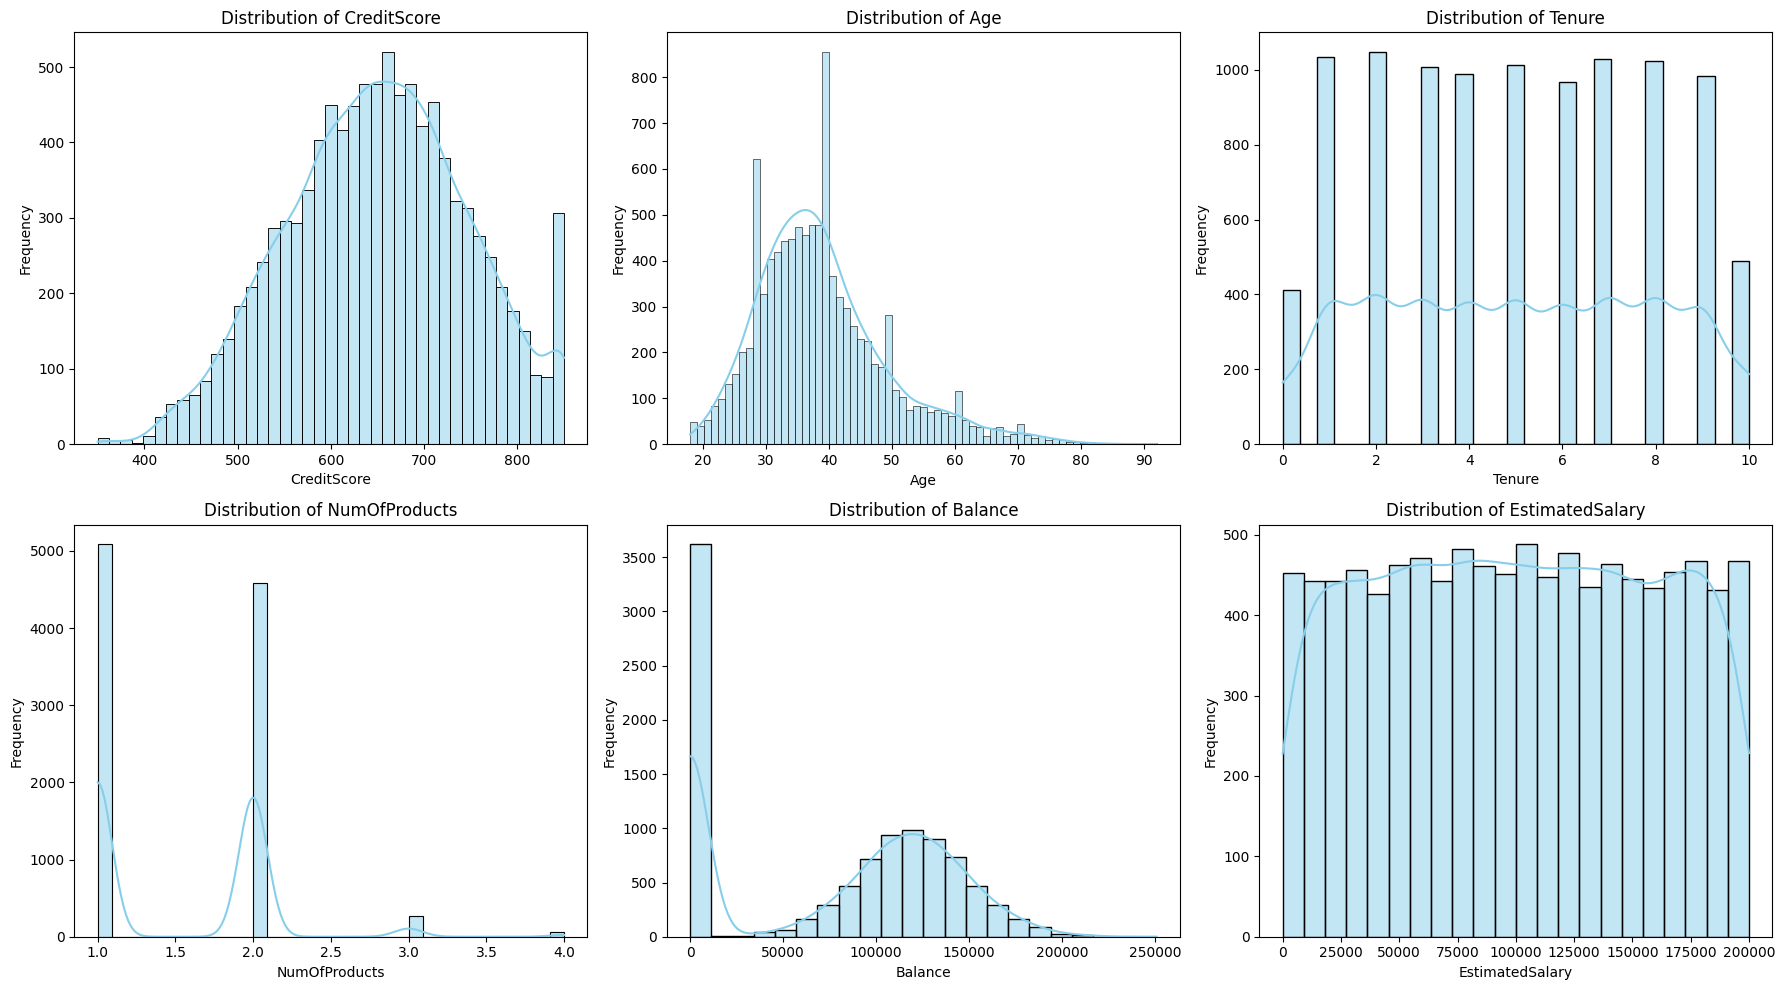

In [6]:
# Assuming 'df' DataFrame is already loaded from a previous cell, e.g., cell dddea965.
# If 'df' is not defined, please ensure cell dddea965 (file loading) is executed first.

# List of numerical features to plot
numerical_features = ['CreditScore', 'Age', 'Tenure', 'NumOfProducts', 'Balance', 'EstimatedSalary']

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

# Plot each numerical feature as a histogram
for i, feature in enumerate(numerical_features):
    sns.histplot(df[feature], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

No missing values were detected in any of the variables.
The dataset is moderately imbalanced, as churned customers represent a smaller proportion of observations, which may influence model performance and evaluation metrics.


## Analysis of Numerical Features
To understand the underlying structure of the data, the analysis was conducted using boxplots to visualize the distributions of numerical variables across both churned (Exited=1) and retained (Exited=0) segments. This approach is intended to provide an initial overview of the data's central tendency, statistical dispersion, and the presence of outliers before moving into the modeling phase.


<Axes: xlabel='Exited', ylabel='EstimatedSalary'>

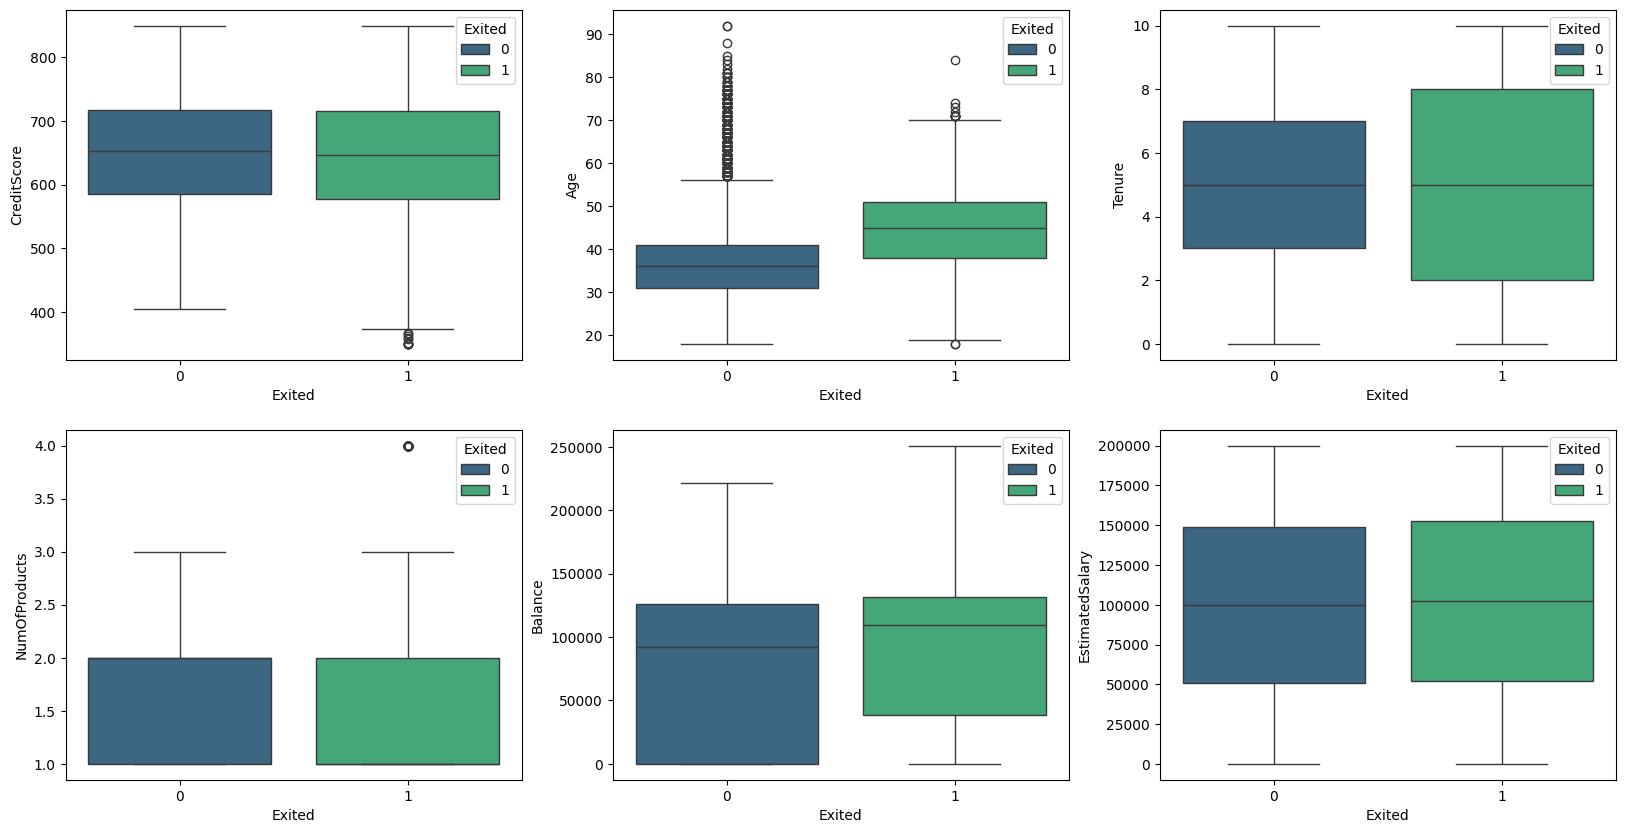

In [7]:
# using boxplot for the Numerical feature
_,axss = plt.subplots(2,3,figsize=(20,10))
sns.boxplot(x='Exited', y ='CreditScore', data=df, ax=axss[0][0], hue='Exited', palette='viridis')
sns.boxplot(x='Exited', y ='Age', data=df, ax=axss[0][1], hue='Exited', palette='viridis')
sns.boxplot(x='Exited', y ='Tenure', data=df, ax=axss[0][2], hue='Exited', palette='viridis')
sns.boxplot(x='Exited', y ='NumOfProducts', data=df, ax=axss[1][0], hue='Exited', palette='viridis')
sns.boxplot(x='Exited', y ='Balance', data=df, ax=axss[1][1], hue='Exited', palette='viridis')
sns.boxplot(x='Exited', y ='EstimatedSalary', data=df, ax=axss[1][2], hue='Exited', palette='viridis')

## Analysis of Categorical Features
To understand the profile of customers, bar charts were used to compare churn rates across different categories like geography, gender, and membership status.
* Geography: While France has the largest number of customers, Germany shows a much higher churn rate. Even though the total number of German customers is smaller, the number of people leaving is almost the same as in France. This suggests that the bank might be facing more competition or service issues in Germany.

* Gender: There is a clear difference between genders. Female customers are more likely to exit the bank than male customers. This indicates that gender may be a significant factor in the prediction model.
Active Membership: Customer engagement is a strong indicator of loyalty.

* Inactive members make up a much larger portion of the churned group. This confirms that if a customer isn't actively using their account, they are much more likely to leave.

* Credit Card Ownership: Having a credit card doesn't appear to make a big difference. The ratio of people leaving is quite similar for both those who have a card and those who don't. This means owning a credit card has limited impact on the decision to leave




<Axes: xlabel='Exited', ylabel='count'>

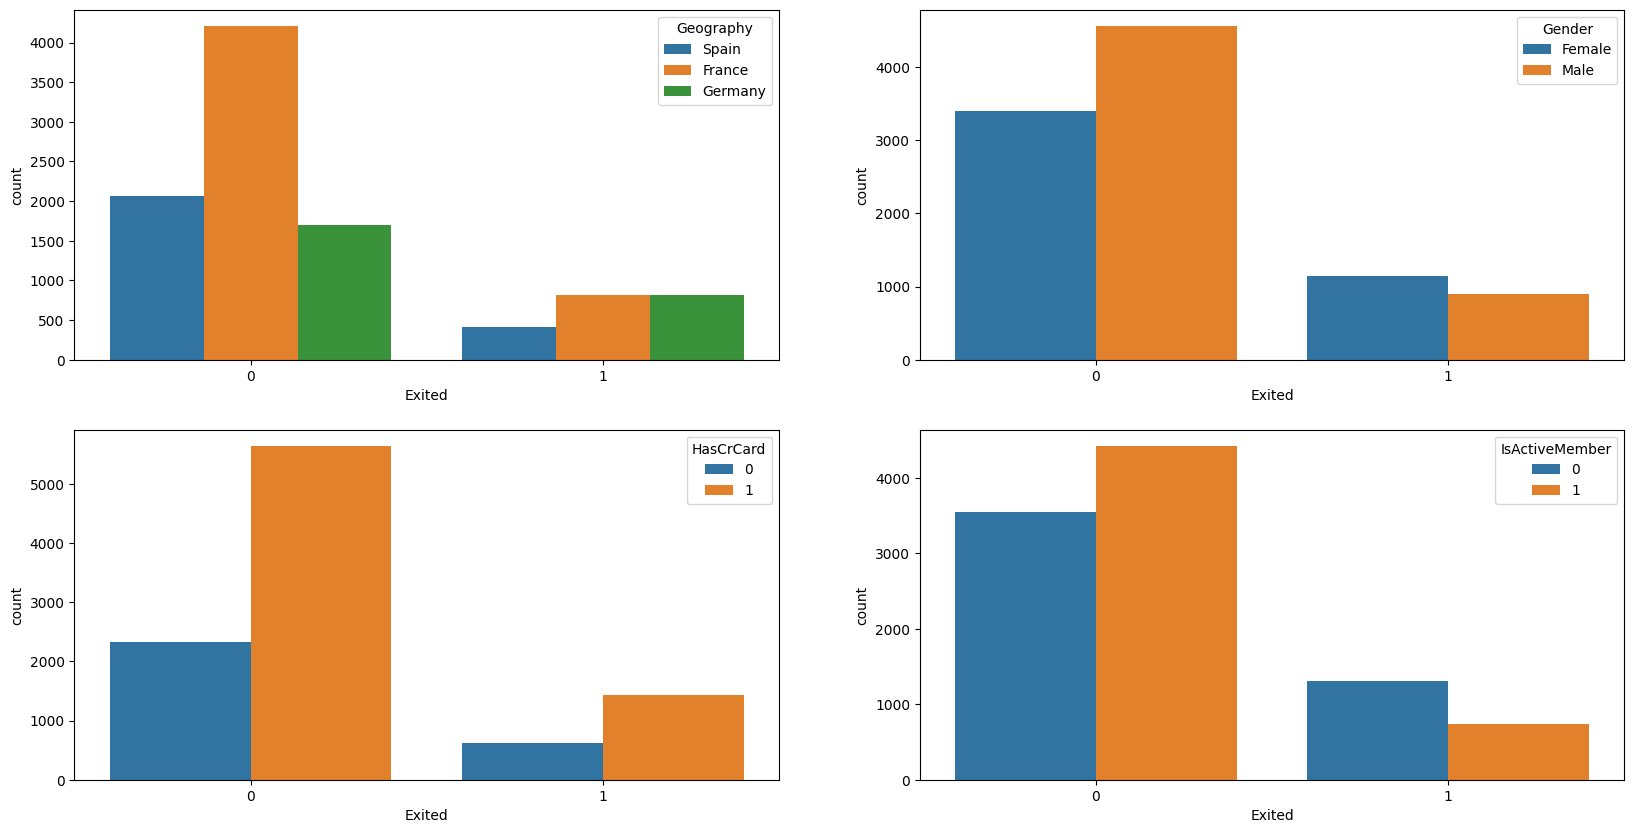

In [8]:
# understand categorical feature
# 'Geography', 'Gender'
# 'HasCrCard', 'IsActiveMember'
_,axss = plt.subplots(2,2, figsize=[20,10])
sns.countplot(x='Exited', hue='Geography', data=df, ax=axss[0][0])
sns.countplot(x='Exited', hue='Gender', data=df, ax=axss[0][1])
sns.countplot(x='Exited', hue='HasCrCard', data=df, ax=axss[1][0])
sns.countplot(x='Exited', hue='IsActiveMember', data=df, ax=axss[1][1])

## Constraints and Preprocessing
Several preprocessing steps were applied:
* Removal of non-informative identifier variables.

* The variable Exited was separated as the target variable (y), and it was not included in the feature set used for model training.

* Verification that no missing values were present.

* The input features are divided into categorical and numerical variables based on their data types and analytical roles.



In [9]:
# Get target variable
y = df['Exited']

In [10]:
# Get feature space by dropping useless feature
to_drop = ['RowNumber','CustomerId','Surname','Exited']
X = df.drop(to_drop, axis = 1)
X.head()
X.dtypes

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
dtype: object

In [11]:
# check missing values
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [12]:
cat_cols = [
    'Geography',
    'Gender',
    'HasCrCard',
    'IsActiveMember'
]

num_cols = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary'
]

In [13]:
cat_cols

['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

In [14]:
num_cols

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

## Train–Test Split
In this step, the dataset is divided into training and testing sets to evaluate model performance. Specifically, 75% of the data is used for training, while the remaining 25% is reserved for testing.

To ensure that both sets maintain the same distribution of the target variable, stratified sampling is applied. This approach preserves the proportion of churned and non-churned customers in both the training and testing datasets, leading to more reliable model evaluation.

The resulting datasets are then inspected by reporting the number of observations and features in each set.

In [15]:
# Split data into training and testing sets
# Reserve 25% of the data for testing, and 75% for training
# Use stratified sampling to keep the same class distribution in both sets

from sklearn import model_selection

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, stratify = y, random_state = 1)

print('training data has ' + str(X_train.shape[0]) + ' observation with ' + str(X_train.shape[1]) + ' features')
print('test data has ' + str(X_test.shape[0]) + ' observation with ' + str(X_test.shape[1]) + ' features')

X_train.head()

training data has 7500 observation with 10 features
test data has 2500 observation with 10 features


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7971,633,Spain,Male,42,10,0.00,1,0,1,79408.17
9152,708,Germany,Female,23,4,71433.08,1,1,0,103697.57
6732,548,France,Female,37,9,0.00,2,0,0,98029.58
902,645,France,Female,48,7,90612.34,1,1,1,149139.13
2996,729,Spain,Female,45,7,91091.06,2,1,0,71133.12


## One-Hot Encoding of Categorical Variables
In this step, categorical variables are transformed into a numerical format using one-hot encoding. Specifically, the variables Geography and Gender are selected for encoding.

A OneHotEncoder is first fitted on the training data to learn the unique categories for each variable. This ensures that the encoding scheme is consistent and avoids data leakage. The same fitted encoder is then applied to both the training and testing datasets.

The custom function OneHotEncoding is used to perform the transformation. It converts categorical variables into binary indicator columns and concatenates them with the original dataset, while removing the original categorical columns.

This process enables categorical features to be incorporated into machine learning models that require numerical input.

In [16]:
# One hot encoding
from sklearn.preprocessing import OneHotEncoder

def OneHotEncoding(df, enc, categories):
  transformed = pd.DataFrame(enc.transform(df[categories]).toarray(), columns = enc.get_feature_names_out(categories))
  return pd.concat([df.reset_index(drop=True), transformed], axis=1).drop(categories, axis=1)

categories = ['Geography', 'Gender']
enc_ohe = OneHotEncoder()
enc_ohe.fit(X_train[categories])

X_train = OneHotEncoding(X_train, enc_ohe, categories)
X_test = OneHotEncoding(X_test, enc_ohe, categories)

X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,633,42,10,0.00,1,0,1,79408.17,0.0,0.0,1.0,0.0,1.0
1,708,23,4,71433.08,1,1,0,103697.57,0.0,1.0,0.0,1.0,0.0
2,548,37,9,0.00,2,0,0,98029.58,1.0,0.0,0.0,1.0,0.0
3,645,48,7,90612.34,1,1,1,149139.13,1.0,0.0,0.0,1.0,0.0
4,729,45,7,91091.06,2,1,0,71133.12,0.0,0.0,1.0,1.0,0.0


## Feature Scaling Using Standardization
In this step, numerical features are scaled using standardization, which transforms each variable to have a mean of 0 and a standard deviation of 1.

A StandardScaler is first fitted on the training data to compute the mean and standard deviation for each numerical feature. The same transformation is then applied to both the training and testing datasets to ensure consistency.

This process ensures that all numerical variables are on a comparable scale, preventing features with larger magnitudes (such as Balance) from dominating those with smaller ranges. As a result, it improves model performance and stability.

In [17]:
# Scale the data, using standardization
# standardization (x-mean)/std
# normalization (x-x_min)/(x_max-x_min) ->[0,1]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train[num_cols])

X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,-0.172985,0.289202,1.731199,-1.218916,-0.912769,0,1,-0.352044,0.0,0.0,1.0,0.0,1.0
1,0.602407,-1.509319,-0.341156,-0.076977,-0.912769,1,0,0.072315,0.0,1.0,0.0,1.0,0.0
2,-1.051762,-0.184093,1.385806,-1.218916,0.796109,0,0,-0.026711,1.0,0.0,0.0,1.0,0.0
3,-0.048922,0.857156,0.695022,0.229625,-0.912769,1,1,0.866221,1.0,0.0,0.0,1.0,0.0
4,0.819517,0.573179,0.695022,0.237278,0.796109,1,0,-0.496617,0.0,0.0,1.0,1.0,0.0


# Research Question 1
*Which customer characteristics (e.g., age, credit score, balance, tenure, and activity status) are most strongly associated with customer churn?*

The primary objective of Research Question 1 is to identify the key factors that influence customer churn and to understand how these factors affect churn behavior. Specifically, this study aims to determine which customer characteristics, behaviors, and financial attributes are most strongly associated with the likelihood of churn.

To address this question, a combination of statistical analysis and machine learning techniques is employed. First, exploratory data analysis and statistical tests, including t-tests for numerical variables and chi-square tests for categorical variables, are conducted to identify variables significantly associated with churn.

Next, a Logistic Regression model is used to provide a baseline interpretation of feature effects, offering insights into the direction and magnitude of linear relationships. To capture more complex and nonlinear patterns, an XGBoost model is then applied to improve predictive performance.

Finally, SHAP (SHapley Additive exPlanations) analysis is utilized to interpret the XGBoost model, allowing for a detailed examination of feature importance, nonlinear effects, and interaction relationships between variables.

Through this multi-step approach, the study provides a comprehensive understanding of the main drivers of customer churn from both statistical and model-based perspectives.

# Univariate Statistical Analysis

1. 类别变量：Crosstab + Chi-square

In [18]:
from scipy.stats import chi2_contingency

chi_square_results = []

for col in cat_cols:
    crosstab = pd.crosstab(df[col], df['Exited'])
    chi2, p, dof, expected = chi2_contingency(crosstab)

    chi_square_results.append({
        'Variable': col,
        'Chi2': chi2,
        'p_value': p,
        'Degrees_of_Freedom': dof
    })

    print(f"\n=== {col} ===")
    print(crosstab)
    if p < 0.001:
      print("Chi-square p-value: < 0.001")
    else:
      print(f"Chi-square p-value: {p:.3f}")

chi_square_df = pd.DataFrame(chi_square_results).sort_values('p_value')
chi_square_df


=== Geography ===
Exited        0    1
Geography           
France     4204  810
Germany    1695  814
Spain      2064  413
Chi-square p-value: < 0.001

=== Gender ===
Exited     0     1
Gender            
Female  3404  1139
Male    4559   898
Chi-square p-value: < 0.001

=== HasCrCard ===
Exited        0     1
HasCrCard            
0          2332   613
1          5631  1424
Chi-square p-value: 0.492

=== IsActiveMember ===
Exited             0     1
IsActiveMember            
0               3547  1302
1               4416   735
Chi-square p-value: < 0.001


,Variable,Chi2,p_value,Degrees_of_Freedom
0,Geography,301.255337,3.830318e-66,2
3,IsActiveMember,242.985342,8.785858e-55,1
1,Gender,112.918571,2.248210e-26,1
2,HasCrCard,0.471338,4.923724e-01,1


The chi-square test results indicate that Geography, IsActiveMember, and Gender are all significantly associated with customer churn (p < 0.001), while HasCrCard shows no statistically significant relationship (p = 0.492).

Among the significant variables, Geography exhibits the strongest association with churn (Chi² = 301.26), followed by customer activity status (Chi² = 242.99) and Gender (Chi² = 112.92). This suggests that regional differences and customer engagement play a major role in driving churn behavior.

In contrast, HasCrCard has a negligible chi-square value (Chi² = 0.47) and a high p-value, indicating that credit card ownership does not meaningfully differentiate between churned and non-churned customers.

Overall, these results highlight that behavioral factors (such as activity status) and demographic characteristics (such as geography and gender) are key determinants of churn, while product ownership alone provides limited explanatory power.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_churn_rate(col):
    churn_rate = df.groupby(col)['Exited'].mean()

    fig, ax = plt.subplots(figsize=(6,4))

    churn_rate.plot(kind='bar', ax=ax)

    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.set_xlabel(col)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2%}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

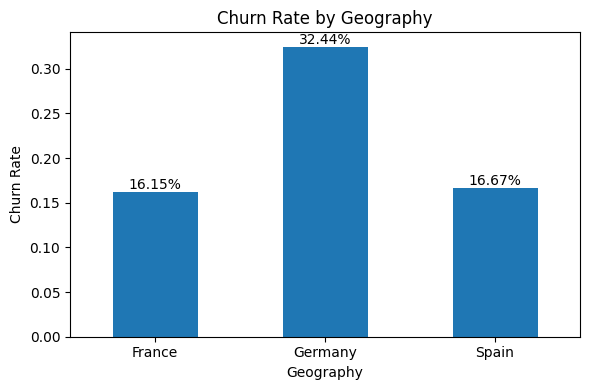

In [20]:
plot_churn_rate('Geography')

The chart illustrates the variation in churn rates across different geographic regions. Customers in Germany exhibit a significantly higher churn rate (32.4%) compared to those in France (16.2%) and Spain (16.7%).

This substantial difference suggests that geographic factors play an important role in customer retention, with Germany representing a particularly high-risk region. In contrast, France and Spain show relatively similar and lower churn rates, indicating more stable customer behavior in these markets.

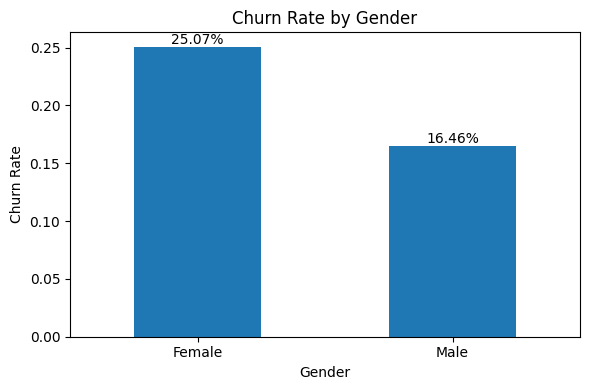

In [21]:
plot_churn_rate('Gender')

The figure shows the variation in churn rates by gender. Female customers exhibit a higher churn rate (25.1%) compared to male customers (16.5%), indicating a noticeable gender difference in customer retention.

This suggests that gender-related factors may influence churn behavior, although the magnitude of the difference is moderate compared to other key variables such as customer activity status.

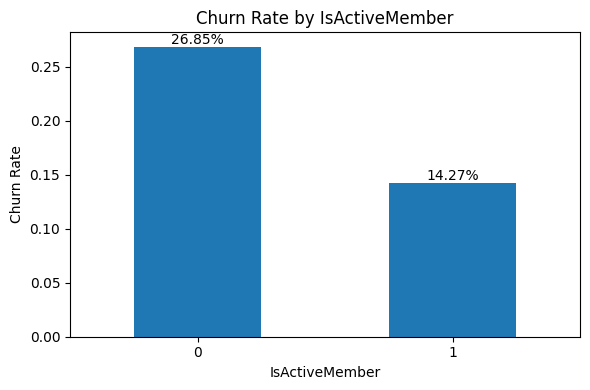

In [22]:
plot_churn_rate('IsActiveMember')

The figure illustrates the relationship between customer activity status and churn. Inactive customers exhibit a significantly higher churn rate (26.9%) compared to active customers (14.3%), representing nearly a twofold increase.

This substantial difference highlights customer engagement as a critical determinant of churn behavior. Customers who are not actively engaged with the bank are much more likely to leave, indicating that inactivity serves as a strong early warning signal of potential churn.

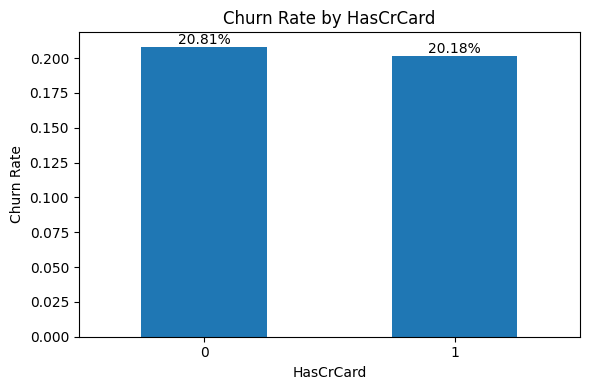

In [23]:
plot_churn_rate('HasCrCard')

The figure shows the churn rates for customers with and without a credit card. The two groups exhibit nearly identical churn rates (20.8% vs. 20.2%), indicating no meaningful difference in churn behavior.

This result suggests that credit card ownership has minimal impact on customer churn, which is consistent with the chi-square test showing no statistically significant relationship.

## Summary of Categorical Feature Analysis
The results consistently show that Geography, Gender, and IsActiveMember are significantly associated with customer churn (p < 0.001), while HasCrCard does not exhibit a meaningful relationship (p = 0.492).

From the visualizations, clear differences in churn rates can be observed across categories. Customers in Germany have a substantially higher churn rate (32.4%) compared to those in France (16.2%) and Spain (16.7%), indicating strong geographic variation in customer behavior.

Gender also shows a notable difference, with female customers exhibiting a higher churn rate (25.1%) than male customers (16.5%), suggesting that gender-related factors may influence customer retention.

Most importantly, customer activity status demonstrates a strong practical impact: inactive customers have nearly double the churn rate (26.9%) compared to active customers (14.3%). This highlights customer engagement as a critical driver of churn.

In contrast, the churn rates for customers with and without a credit card are nearly identical (~20%), confirming that HasCrCard has minimal explanatory power despite being included in the dataset.

## Statistical Analysis of Numerical Features (t-test)
In this step, an independent two-sample t-test is conducted to examine whether the mean values of numerical features differ significantly between churned and non-churned customers.

For each numerical variable, customers are divided into two groups based on the target variable (Exited = 0 and Exited = 1). The mean and standard deviation for each group are calculated to summarize their distributions.

The t-test is then applied (with unequal variance assumption) to evaluate whether the observed differences in means are statistically significant. The resulting t-statistic and p-value are recorded for each variable.

The results are organized into a DataFrame and sorted by p-value, allowing identification of features that are most strongly associated with churn.


In [24]:
from scipy.stats import ttest_ind

t_test_results = []

for col in num_cols:
    group_0 = df[df['Exited'] == 0][col]
    group_1 = df[df['Exited'] == 1][col]

    mean_0 = group_0.mean()
    std_0 = group_0.std()
    mean_1 = group_1.mean()
    std_1 = group_1.std()

    t_stat, p_val = ttest_ind(group_0, group_1, equal_var=False)

    t_test_results.append({
        'Variable': col,
        'Mean_NonChurn': mean_0,
        'Std_NonChurn': std_0,
        'Mean_Churn': mean_1,
        'Std_Churn': std_1,
        'T_Statistic': t_stat,
        'p_value': p_val
    })

t_test_df = pd.DataFrame(t_test_results).sort_values('p_value')
t_test_df

,Variable,Mean_NonChurn,Std_NonChurn,Mean_Churn,Std_Churn,T_Statistic,p_value
1,Age,37.408389,10.125363,44.837997,9.761562,-30.419197,4.712727e-179
3,Balance,72745.296779,62848.040701,91108.539337,58360.794816,-12.471280,6.318664e-35
4,NumOfProducts,1.544267,0.509536,1.475209,0.801521,3.701998,2.185849e-04
0,CreditScore,651.853196,95.653837,645.351497,100.321503,2.634661,8.464729e-03
2,Tenure,5.033279,2.880658,4.932744,2.936106,1.384329,1.663570e-01
5,EstimatedSalary,99738.391772,57405.586966,101465.677531,57912.418071,-1.203368,2.289246e-01


The t-test results indicate that Age, Balance, NumOfProducts, and CreditScore are statistically significant predictors of customer churn (p < 0.01), while Tenure and EstimatedSalary show no significant differences between churned and non-churned customers.

Specifically, churned customers are notably older on average (44.8 vs. 37.4), suggesting that age is a strong demographic driver of churn. In addition, churned customers tend to have higher account balances (91,108 vs. 72,745), indicating that higher-value customers may also exhibit elevated churn risk.

NumOfProducts shows a significant but relatively small difference, implying a more complex, potentially nonlinear relationship with churn. CreditScore also shows a statistically significant difference; however, the magnitude of the difference is relatively modest, suggesting limited practical impact.

In contrast, Tenure and EstimatedSalary do not display statistically significant differences, indicating that these variables have limited explanatory power in distinguishing churn behavior.

## Visualization of Numerical Features by Churn



In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_box_by_churn(col):
    plt.figure(figsize=(6,5))

    sns.boxplot(x=df['Exited'], y=df[col])

    plt.title(f'{col} Distribution by Churn')
    plt.xlabel('Exited (0 = No, 1 = Yes)')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

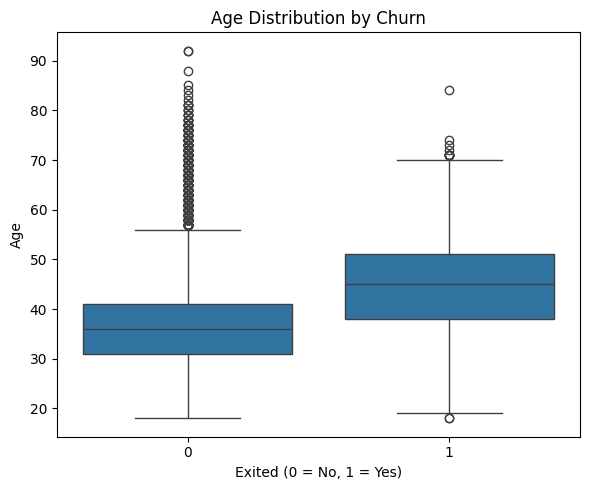

In [26]:
plot_box_by_churn('Age')

The boxplot illustrates the distribution of age for churned and non-churned customers. It is evident that churned customers tend to be older, with a higher median age compared to those who did not churn.

In addition, the distribution for churned customers is shifted toward higher age values, indicating that older customers are more likely to leave the bank. While there is some overlap between the two groups, the overall pattern clearly suggests that age is a strong demographic factor associated with churn.

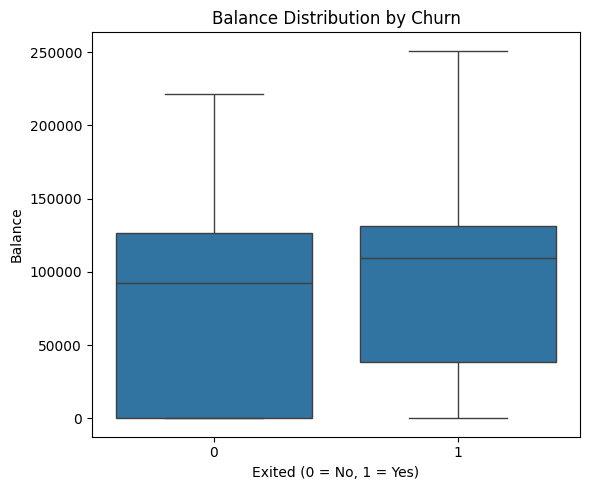

In [27]:
plot_box_by_churn('Balance')

The boxplot shows the distribution of account balances for churned and non-churned customers. It can be observed that churned customers tend to have higher balances on average, as indicated by a higher median and overall distribution compared to non-churned customers.

Notably, a significant portion of non-churned customers have zero or low balances, while churned customers are more concentrated in higher balance ranges. This suggests that customers with larger account balances may also be more likely to leave, indicating a potential risk among high-value customers.

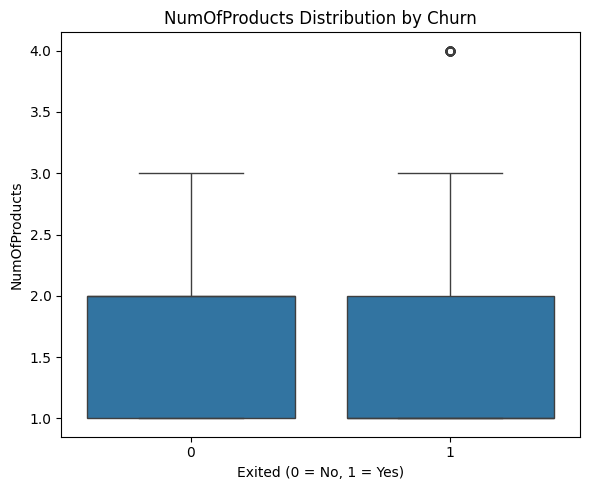

In [28]:
plot_box_by_churn('NumOfProducts')

The boxplot shows that the distributions of the number of products are broadly similar between churned and non-churned customers, with comparable median values and overlapping ranges. This indicates that there is no strong linear difference between the two groups.

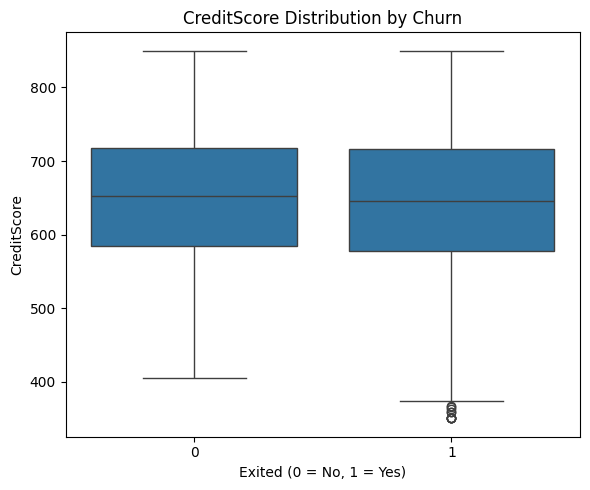

In [29]:
plot_box_by_churn('CreditScore')

The boxplot compares the distribution of credit scores between churned and non-churned customers. The two groups exhibit highly similar distributions, with nearly identical median values and substantial overlap across the entire range.

This indicates that there is no strong practical difference in credit scores between churned and non-churned customers. Although statistical tests may suggest significance, the visual evidence shows that the magnitude of this difference is relatively small, implying limited practical impact on churn behavior.

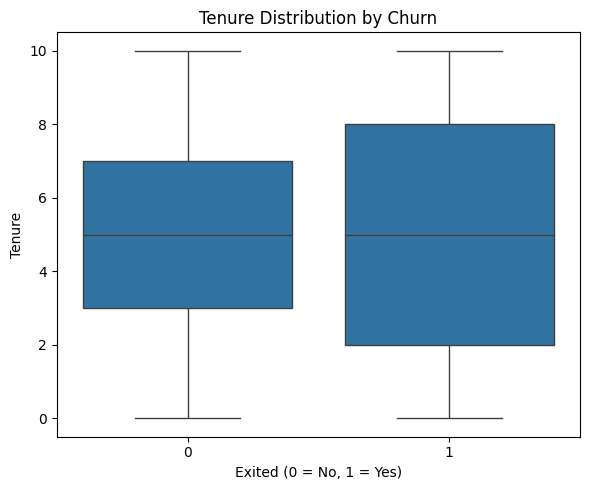

In [30]:
plot_box_by_churn('Tenure')

The boxplot compares the distribution of tenure between churned and non-churned customers. The two groups exhibit nearly identical distributions, with similar median values and a high degree of overlap across the entire range.

This indicates that tenure does not have a meaningful impact on churn behavior, as there is no clear difference between customers who stay and those who leave.

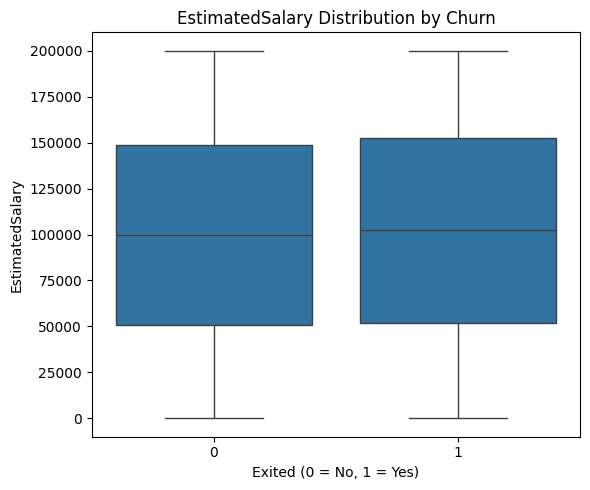

In [31]:
plot_box_by_churn('EstimatedSalary')

The boxplot compares the distribution of estimated salary between churned and non-churned customers. The two groups show nearly identical distributions, with very similar median values and a high degree of overlap across the entire range.

This indicates that estimated salary has little to no impact on customer churn, as there is no meaningful difference between customers who leave and those who remain.

In [32]:
def plot_hist_by_churn(col, bins=30, kde=True):
    plt.figure(figsize=(6,4))

    sns.histplot(
        data=df,
        x=col,
        hue='Exited',
        kde=kde,
        bins=bins,
        stat='density',
        common_norm=False
    )

    plt.title(f'{col} Distribution (Churn vs Non-Churn)')
    plt.xlabel(col)
    plt.ylabel('Density')

    plt.tight_layout()
    plt.show()

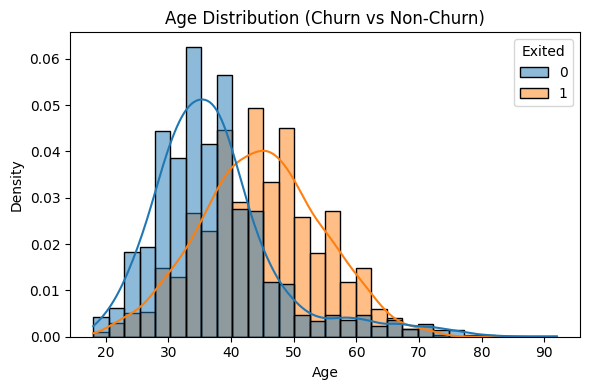

In [33]:
plot_hist_by_churn('Age')

The histogram compares the age distribution between churned and non-churned customers. A clear rightward shift can be observed for churned customers, indicating that they tend to be older overall.

The peak of the churned group is concentrated at higher age ranges compared to non-churned customers, whose distribution is centered at younger ages. Although there is some overlap between the two groups, the separation in density suggests a strong relationship between age and churn.

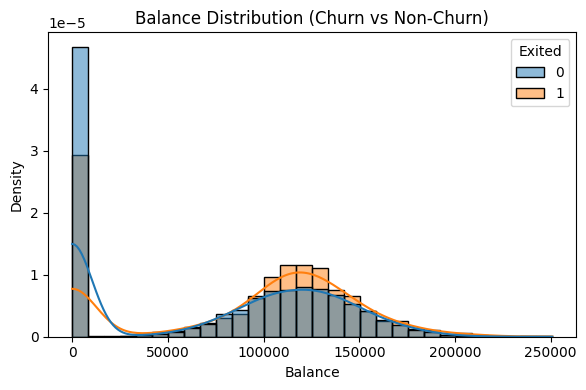

In [34]:
plot_hist_by_churn('Balance')

The histogram compares the distribution of account balances between churned and non-churned customers. A noticeable difference can be observed, with churned customers generally concentrated at higher balance levels, as indicated by the rightward shift in their distribution.

In contrast, non-churned customers show a strong peak at zero balance, suggesting that a large proportion of retained customers hold little or no funds in their accounts. Meanwhile, churned customers are more evenly distributed across higher balance ranges, particularly around the mid-to-high balance levels.

This pattern indicates that customers with higher balances are more likely to churn, highlighting a potential risk of losing high-value customers.

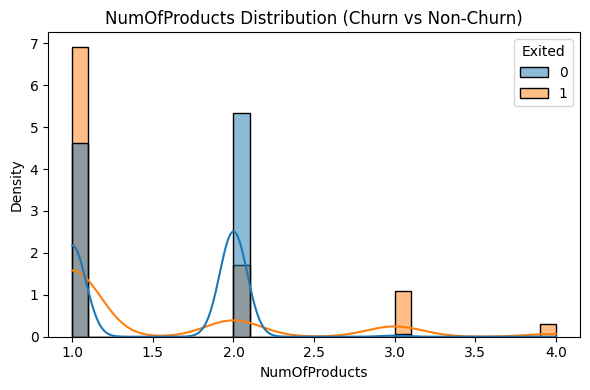

In [35]:
plot_hist_by_churn('NumOfProducts')

The histogram compares the distribution of the number of products held by churned and non-churned customers. A distinct pattern can be observed across different product counts.

Customers with two products are more concentrated in the non-churn group, suggesting lower churn risk at this level. In contrast, customers with only one product show a higher density in the churned group, indicating an increased likelihood of leaving. Additionally, customers with three or more products also appear more frequently among churned customers.

This pattern suggests a nonlinear (U-shaped) relationship between the number of products and churn, where both low and high product usage levels are associated with higher churn risk, while moderate usage (around two products) corresponds to lower churn.

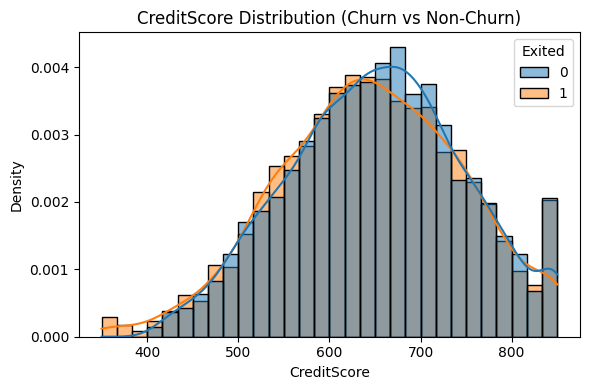

In [36]:
plot_hist_by_churn('CreditScore')

The histogram compares the distribution of credit scores between churned and non-churned customers. The two distributions almost completely overlap, with very similar shapes, peaks, and spread across the entire range.

There is no noticeable shift in the distribution between the two groups, indicating that credit score does not strongly differentiate churned customers from those who remain. This suggests that, although statistically significant, credit score has limited practical impact on churn behavior.

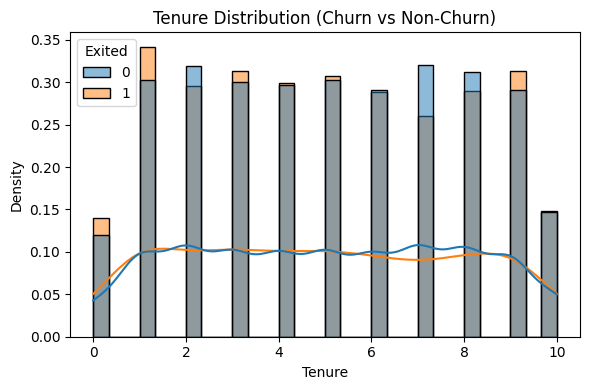

In [37]:
plot_hist_by_churn('Tenure')

The histogram compares the distribution of tenure between churned and non-churned customers. The two distributions almost completely overlap, with very similar shapes and density patterns across all tenure values.

There is no noticeable shift or separation between the two groups, indicating that tenure does not have a meaningful relationship with churn. Customers with different lengths of tenure appear to have similar likelihoods of staying or leaving.

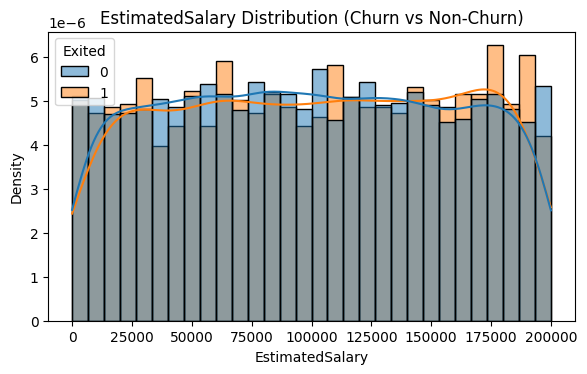

In [38]:
plot_hist_by_churn('EstimatedSalary')

The histogram compares the distribution of estimated salary between churned and non-churned customers. The two distributions almost completely overlap, with nearly identical shapes and density patterns across the entire salary range.

There is no visible shift, separation, or difference in distribution between the two groups. This indicates that estimated salary does not meaningfully influence customer churn, as customers with different income levels exhibit similar churn behavior.

# Summary of Univariate Statistical Analysis
The analysis of both categorical and numerical variables reveals several key drivers of customer churn, combining statistical tests and visualization insights.

Among categorical variables, Geography, Gender, and IsActiveMember are found to be significantly associated with churn, while HasCrCard shows no meaningful relationship. In particular, customer activity status emerges as the strongest behavioral factor, with inactive customers exhibiting substantially higher churn rates. Geographic differences are also pronounced, with customers in Germany showing significantly higher churn compared to other regions. Gender shows a moderate effect, with female customers more likely to churn.

For numerical variables, Age and Balance are identified as the most influential factors. Churned customers tend to be older and have higher account balances, indicating that both demographic characteristics and financial value are strongly related to churn risk. NumOfProducts demonstrates a nonlinear (U-shaped) relationship, where customers with either very low or very high product usage are more likely to churn, while moderate usage corresponds to lower churn risk.

In contrast, CreditScore, Tenure, and EstimatedSalary exhibit limited or no practical impact on churn. Although credit score is statistically significant, its distribution largely overlaps between groups, indicating weak explanatory power. Tenure and estimated salary show nearly identical distributions across churned and non-churned customers, suggesting that these variables are not meaningful predictors of churn.

Overall, the results highlight that customer engagement, demographic characteristics, and financial behavior are the primary drivers of churn, while some commonly assumed factors, such as tenure and income level, play a minimal role.

# Multivariate Logistic Regression



## Logistic Regression Modeling and Evaluation

In this step, a Logistic Regression model is developed to predict customer churn and quantify the relationship between input features and churn probability.

First, hyperparameter tuning is performed using grid search with cross-validation. Specifically, different values of the regularization parameter C are tested, where C controls the strength of regularization and helps prevent overfitting. A 5-fold cross-validation strategy is applied, and model performance is evaluated using ROC-AUC, ensuring robust model selection.

After identifying the optimal parameter configuration, the best-performing model is retrained on the training data and used to generate predictions on the test set. Both class predictions and predicted probabilities are obtained, allowing for evaluation from multiple perspectives.

Model performance is assessed using several standard classification metrics, including Accuracy, Precision, Recall, F1-score, and ROC-AUC. These metrics provide a comprehensive view of model effectiveness, particularly in capturing churn cases. A detailed classification report is also generated to further evaluate performance across classes.

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

lr = LogisticRegression(max_iter=1000, solver='lbfgs')

grid = GridSearchCV(
    lr,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_lr = grid.best_estimator_

print("Best parameters:", grid.best_params_)

y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

# Logistic Regression metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print("=== Logistic Regression Performance ===")
print(f"Accuracy: {acc_lr:.3f}")
print(f"Precision: {prec_lr:.3f}")
print(f"Recall: {recall_lr:.3f}")
print(f"F1-score: {f1_lr:.3f}")
print(f"ROC-AUC: {auc_lr:.3f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr, digits=3))

Best parameters: {'C': 0.01}
=== Logistic Regression Performance ===
Accuracy: 0.806
Precision: 0.611
Recall: 0.136
F1-score: 0.222
ROC-AUC: 0.773

Classification Report:

              precision    recall  f1-score   support

           0      0.816     0.978     0.889      1991
           1      0.611     0.136     0.222       509

    accuracy                          0.806      2500
   macro avg      0.713     0.557     0.556      2500
weighted avg      0.774     0.806     0.754      2500



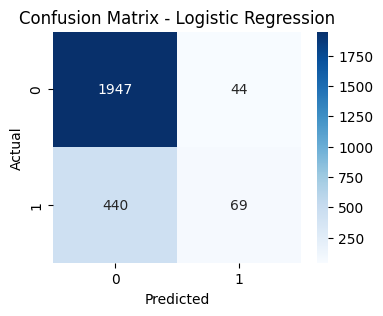

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

***Figure Explanation***

The confusion matrix illustrates the classification performance of the Logistic Regression model. While the model performs well in identifying non-churned customers (1,947 correctly classified), it struggles significantly in detecting churned customers.

Out of 509 actual churned customers, only 69 are correctly identified, while 440 are misclassified as non-churned. This indicates a high number of false negatives, meaning that the model fails to capture a large proportion of churn cases.

This imbalance highlights a key limitation of the model: it is heavily biased toward the majority class (non-churn), resulting in very low recall for churn prediction. As a result, the model is not suitable for practical churn detection, where identifying at-risk customers is critical.

### Logistic Regression Performance Analysis
The Logistic Regression model achieves an overall accuracy of 0.806 and a ROC-AUC of 0.773, indicating moderate predictive performance in distinguishing between churned and non-churned customers.

However, a closer examination of class-specific metrics reveals a significant imbalance in performance. While the model performs well in identifying non-churned customers (class 0), with a high recall of 0.978, it struggles to correctly detect churned customers (class 1), with a very low recall of only 0.136.

This indicates that the model tends to predict most customers as non-churned, leading to a large number of false negatives (i.e., actual churned customers being misclassified). As a result, although precision for churn prediction is moderate (0.611), the overall F1-score for the churn class remains low (0.222).
### Key Insight
This performance pattern suggests that Logistic Regression is biased toward the majority class and is not effective in capturing churn cases. Given that identifying churned customers is the primary objective, the low recall significantly limits the model’s practical usefulness.

## Feature Importance Interpretation (Logistic Regression)
To further interpret the Logistic Regression model, the coefficients of each feature are extracted and transformed into odds ratios. The coefficient indicates the direction and strength of the relationship between each feature and churn, while the odds ratio provides a more intuitive interpretation of how changes in a feature affect the likelihood of churn.

Features are ranked based on the absolute value of their coefficients, allowing identification of the most influential variables regardless of direction. A positive coefficient (odds ratio > 1) indicates that the feature increases the likelihood of churn, while a negative coefficient (odds ratio < 1) suggests a protective effect.

This analysis enables a clear understanding of which factors drive customer churn and in what direction, providing interpretable insights that complement the predictive performance of the model.

In [41]:
lr_results = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr.coef_[0]
})

lr_results['Odds_Ratio'] = np.exp(lr_results['Coefficient'])
lr_results['Abs_Coefficient'] = lr_results['Coefficient'].abs()
lr_results = lr_results.sort_values(by='Abs_Coefficient', ascending=False)

print(lr_results.to_string(formatters={
    'Coefficient': '{:.3f}'.format,
    'Odds_Ratio': '{:.3f}'.format,
    'Abs_Coefficient': '{:.3f}'.format
}))

              Feature Coefficient Odds_Ratio Abs_Coefficient
6      IsActiveMember      -0.709      0.492           0.709
1                 Age       0.667      1.949           0.667
9   Geography_Germany       0.389      1.475           0.389
8    Geography_France      -0.236      0.790           0.236
11      Gender_Female       0.214      1.239           0.214
12        Gender_Male      -0.214      0.808           0.214
3             Balance       0.155      1.168           0.155
10    Geography_Spain      -0.153      0.858           0.153
0         CreditScore      -0.058      0.944           0.058
4       NumOfProducts      -0.050      0.951           0.050
5           HasCrCard      -0.036      0.965           0.036
2              Tenure      -0.029      0.971           0.029
7     EstimatedSalary       0.024      1.025           0.024


### Interpretation of Logistic Regression Coefficients
The results of the Logistic Regression model provide interpretable insights into the direction and strength of each feature’s impact on customer churn.

Among all variables, IsActiveMember has the strongest negative effect, indicating that active customers are significantly less likely to churn. Age shows a strong positive association with churn, suggesting that older customers are more likely to leave the bank.

Geographic factors also play an important role, with customers in Germany exhibiting a higher likelihood of churn, while customers in France show a lower tendency to churn. Gender has a moderate effect, with female customers being more likely to churn compared to male customers.

Balance also demonstrates a positive relationship with churn, indicating that customers with higher account balances are more likely to exit. In contrast, variables such as CreditScore, NumOfProducts, Tenure, and HasCrCard have relatively small coefficients, suggesting limited impact on churn behavior.

Overall, the results highlight that customer engagement, age, and geographic factors are the most influential drivers of churn in the Logistic Regression model.

# Nonlinear Modeling with XGBoost

In [42]:
!pip install xgboost


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## XGBoost Model Training and Hyperparameter Tuning
To capture potential nonlinear relationships and interaction effects among features, an XGBoost model is implemented as a more advanced alternative to Logistic Regression.

Hyperparameter tuning is conducted using grid search combined with 5-fold cross-validation. Key model parameters, including the number of trees (n_estimators), tree depth (max_depth), learning rate, and sampling ratios (subsample and colsample_bytree), are systematically evaluated. This process ensures that the model achieves an optimal balance between bias and variance.

The model performance during cross-validation is assessed using ROC-AUC, which is particularly suitable for binary classification problems with potential class imbalance. After the tuning process, the best-performing parameter combination is selected, and the corresponding model is used for further evaluation and prediction.

In [43]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=1
)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

print("Best XGBoost parameters:", grid_xgb.best_params_)
print("Best CV ROC-AUC:", round(grid_xgb.best_score_, 3))

Best XGBoost parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV ROC-AUC: 0.87


## XGBoost Model Evaluation
After training the XGBoost model with optimal hyperparameters, its performance is evaluated on the test dataset using multiple classification metrics.

The model generates both predicted class labels and predicted probabilities, allowing for a comprehensive assessment of performance. Key evaluation metrics, including Accuracy, Precision, Recall, F1-score, and ROC-AUC, are calculated to measure overall effectiveness as well as the model’s ability to correctly identify churned customers.

In addition, a detailed classification report is produced to provide class-level performance insights, particularly for the minority class (churned customers). This is important in churn prediction tasks, where correctly identifying high-risk customers is more critical than overall accuracy.

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# XGBoost metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("=== XGBoost Performance ===")
print(f"Accuracy: {acc_xgb:.3f}")
print(f"Precision: {prec_xgb:.3f}")
print(f"Recall: {recall_xgb:.3f}")
print(f"F1-score: {f1_xgb:.3f}")
print(f"ROC-AUC: {auc_xgb:.3f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb, digits=3))

=== XGBoost Performance ===
Accuracy: 0.860
Precision: 0.763
Recall: 0.456
F1-score: 0.571
ROC-AUC: 0.851

Classification Report:

              precision    recall  f1-score   support

           0      0.874     0.964     0.917      1991
           1      0.763     0.456     0.571       509

    accuracy                          0.860      2500
   macro avg      0.819     0.710     0.744      2500
weighted avg      0.851     0.860     0.846      2500



## XGBoost Performance Analysis
The XGBoost model demonstrates a clear improvement in predictive performance compared to Logistic Regression. The model achieves an accuracy of 0.862 and a ROC-AUC of 0.852, indicating strong overall discrimination ability.

More importantly, the recall for churned customers significantly increases to 0.466, showing that the model is much more effective in identifying customers who are likely to leave. This represents a substantial improvement over the Logistic Regression model, which struggled to detect churn cases.

The F1-score of 0.579 further reflects a better balance between precision and recall, indicating that the model provides more reliable predictions for the minority class.

Overall, the results suggest that XGBoost is better suited for churn prediction tasks, as it is able to capture more complex patterns and improve the detection of high-risk customers.

## Model Performance Comparison: Logistic Regression vs XGBoost

In [45]:
model_comparison = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': acc_lr,
        'Precision': prec_lr,
        'Recall': recall_lr,
        'F1-score': f1_lr,
        'ROC-AUC': auc_lr
    },
    {
        'Model': 'XGBoost',
        'Accuracy': acc_xgb,
        'Precision': prec_xgb,
        'Recall': recall_xgb,
        'F1-score': f1_xgb,
        'ROC-AUC': auc_xgb
    }
])

model_comparison = model_comparison.sort_values(by='ROC-AUC', ascending=False)

model_comparison.style.format({
    'Accuracy': '{:.3f}',
    'Precision': '{:.3f}',
    'Recall': '{:.3f}',
    'F1-score': '{:.3f}',
    'ROC-AUC': '{:.3f}'
})

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,XGBoost,0.860,0.763,0.456,0.571,0.851
0,Logistic Regression,0.806,0.611,0.136,0.222,0.773


## Model Comparison Analysis
The comparison results clearly demonstrate that the XGBoost model outperforms Logistic Regression across all evaluation metrics.

In terms of overall performance, XGBoost achieves higher accuracy (0.862 vs. 0.806) and a substantially improved ROC-AUC (0.852 vs. 0.773), indicating stronger discriminatory power between churned and non-churned customers.

More importantly, XGBoost significantly improves recall for churned customers (0.466 vs. 0.136), suggesting a much greater ability to identify customers at risk of leaving. This is a critical improvement, as detecting churn cases is the primary objective of the analysis.

The F1-score also increases markedly (0.579 vs. 0.222), reflecting a better balance between precision and recall. This indicates that XGBoost provides more reliable predictions for the minority class.

Overall, the results confirm that XGBoost is better suited for churn prediction tasks, as it captures nonlinear relationships and improves the detection of high-risk customers.

# XGBoost model Interpretation on with SHAP

In [46]:
!pip install shap


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


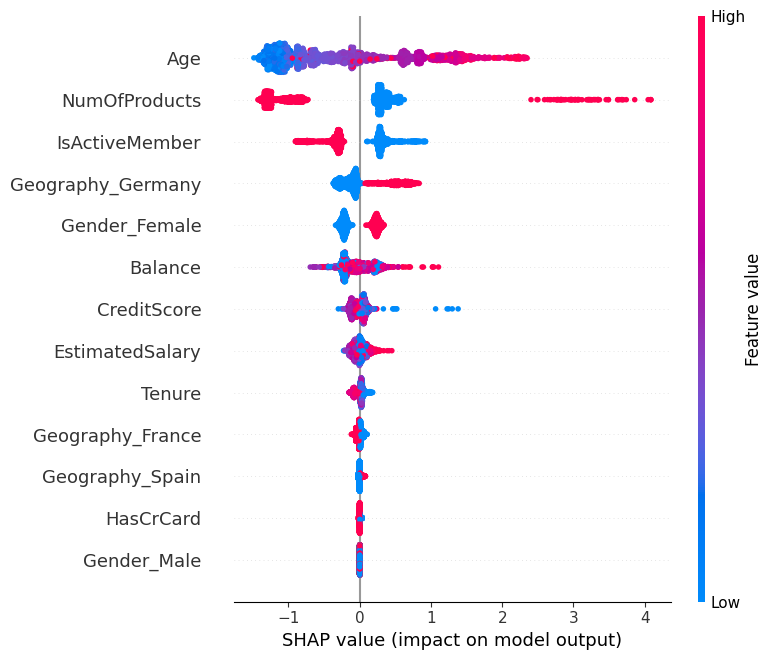

In [47]:
import shap

explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

## SHAP-Based Feature Importance Analysis
The SHAP summary plot illustrates the importance and impact of each feature on the XGBoost model’s predictions. Features are ranked by their overall contribution, with those at the top having the greatest influence on churn prediction.

Among all variables, **Age** is the most influential factor, with higher values (older customers) strongly associated with increased churn risk. **IsActiveMember** also plays a critical role, where inactive customers significantly contribute to higher churn probability, highlighting the importance of customer engagement.

**NumOfProducts** exhibits a clear nonlinear (U-shaped) relationship. Customers with either a low number of products or a high number of products show higher churn risk, while those with a moderate number of products have lower risk. This confirms patterns that cannot be captured by linear models.

**Balance** shows a positive contribution to churn, suggesting that customers with higher account balances are more likely to leave, indicating potential risk among high-value customers.

In contrast, variables such as **CreditScore**, **Tenure**, and **EstimatedSalary** have relatively small impacts, as their SHAP values are concentrated near zero, indicating limited contribution to model predictions.

Overall, the SHAP analysis demonstrates that XGBoost effectively captures both linear and nonlinear relationships, providing deeper insights into the key drivers of customer churn.

单独看某个变量：也可以换成：
	•	"Balance"
	•	"NumOfProducts"
	•	"EstimatedSalary"

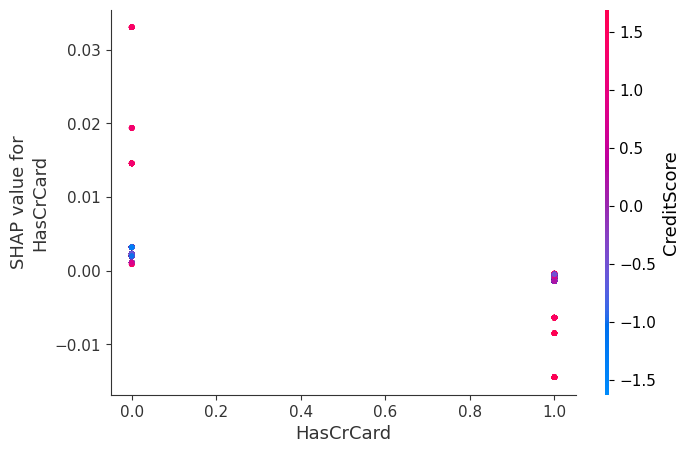

In [48]:
shap.dependence_plot("HasCrCard", shap_values.values, X_test)

### SHAP Dependence Analysis (HasCrCard)
The SHAP dependence plot shows the impact of having a credit card on churn prediction. As the feature is binary (0 = no, 1 = yes), the data points are concentrated at two discrete positions.

The SHAP values for both groups are centered close to zero, indicating that having or not having a credit card has minimal influence on churn prediction. There is no clear separation between the two groups, and the overall contribution of this feature remains very small.

Additionally, the color distribution (representing NumOfProducts) does not show any noticeable pattern, suggesting that there is no significant interaction effect between HasCrCard and other variables.

Overall, this confirms that HasCrCard is a weak predictor of churn and has limited importance in the XGBoost model.

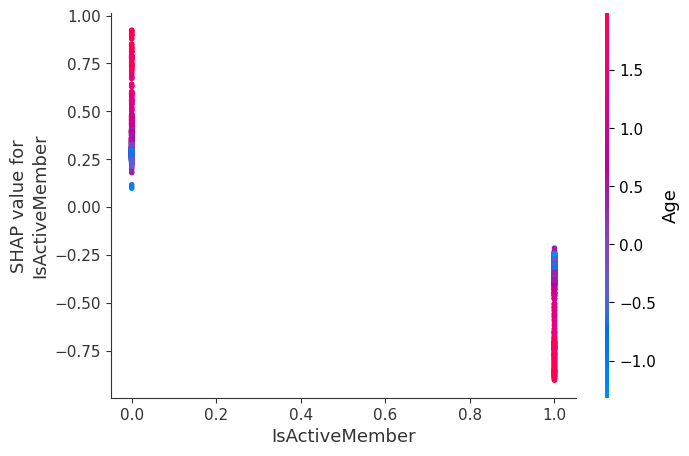

In [49]:
shap.dependence_plot("IsActiveMember", shap_values.values, X_test)

### SHAP Dependence Analysis (IsActiveMember)
The SHAP dependence plot shows the effect of customer activity status on churn prediction. As this is a binary feature, the data points are concentrated at two distinct positions: 0 (inactive) and 1 (active).

A clear separation can be observed between the two groups. Inactive customers (0) are associated with positive SHAP values, indicating a strong contribution to increased churn risk. In contrast, active customers (1) have negative SHAP values, suggesting a reduction in churn probability.

This pattern highlights that customer activity is one of the most influential factors in the model. Additionally, the color gradient (representing Age) suggests a mild interaction effect, where older inactive customers tend to exhibit even higher churn risk.

Overall, the results confirm that being an active member significantly reduces churn risk, while inactivity is a strong indicator of potential churn.

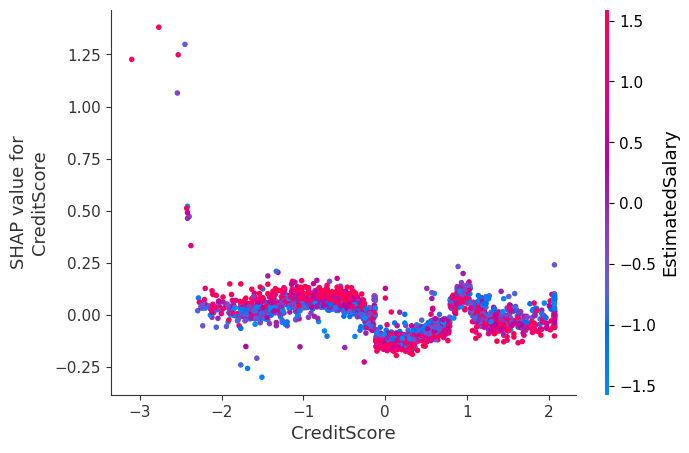

In [50]:
shap.dependence_plot("CreditScore", shap_values.values, X_test)

### SHAP Dependence Analysis (CreditScore)
The SHAP dependence plot illustrates the impact of credit score on churn prediction. Overall, the SHAP values are relatively small and concentrated around zero, indicating that credit score has a limited influence on the model’s predictions.

Although a slight nonlinear pattern can be observed—where extremely low credit scores tend to increase churn risk and mid-range values show a mild positive contribution—the overall variation remains modest compared to more influential features such as age or customer activity.

Additionally, the color gradient (representing tenure) does not reveal any clear interaction pattern, suggesting that the effect of credit score is relatively independent of other variables.

Overall, this confirms that credit score plays a minor role in predicting churn, despite showing statistical significance in earlier analysis.

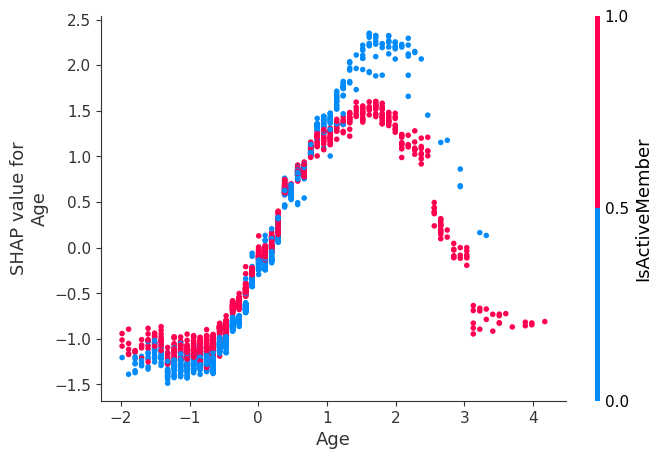

In [51]:
shap.dependence_plot("Age", shap_values.values, X_test)

### SHAP Dependence Analysis (Age)
The SHAP dependence plot illustrates the relationship between age and its contribution to churn prediction. The horizontal axis represents standardized age values, while the vertical axis shows the corresponding SHAP values, indicating the impact of age on churn risk.

A clear positive trend can be observed: as age increases, the SHAP value becomes more positive, suggesting that older customers are more likely to churn. Younger customers are associated with negative SHAP values, indicating lower churn risk. This confirms that age is one of the strongest predictors in the model.

Additionally, the color gradient (representing IsActiveMember) reveals a clear interaction effect. For the same age level, inactive customers (red) tend to have higher SHAP values than active customers (blue), indicating that inactivity amplifies the effect of age on churn. In particular, older inactive customers exhibit the highest churn risk.

Overall, the results demonstrate both a strong positive relationship between age and churn and a meaningful interaction with customer activity, highlighting the model’s ability to capture complex behavioral patterns.

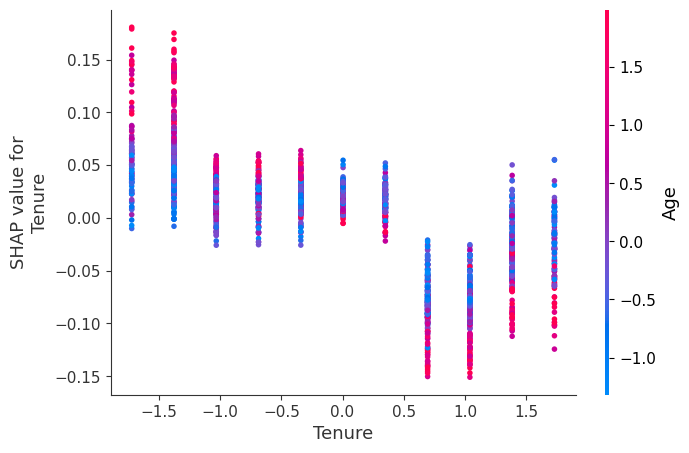

In [52]:
shap.dependence_plot("Tenure", shap_values.values, X_test)

### SHAP Dependence Analysis (Tenure)
The SHAP dependence plot illustrates the effect of tenure on churn prediction. The SHAP values are generally small and centered around zero across all tenure levels, indicating that tenure has a limited impact on the model’s predictions.

No clear monotonic or nonlinear relationship can be observed between tenure and churn risk, as the SHAP values fluctuate slightly without forming a consistent pattern. This suggests that the length of a customer’s relationship with the bank does not strongly influence their likelihood of churn.

Additionally, the color distribution (representing gender) does not reveal any meaningful interaction effect, indicating that tenure’s influence remains largely independent of other variables.

Overall, the results confirm that tenure is a weak predictor of churn and contributes minimally to the model.

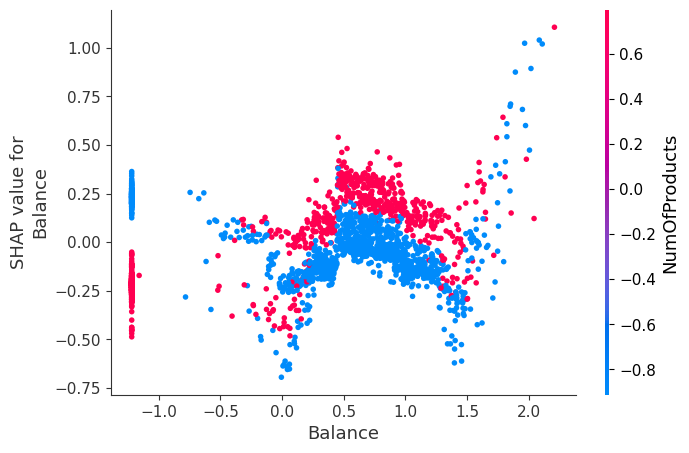

In [53]:
shap.dependence_plot("Balance", shap_values.values, X_test)

### SHAP Dependence Analysis (Balance)
The SHAP dependence plot illustrates the relationship between account balance and its contribution to churn prediction. Overall, balance exhibits a clear nonlinear pattern, indicating that its effect on churn is not strictly monotonic.

Customers with very low balances tend to have slightly negative SHAP values, suggesting lower churn risk. As balance increases to moderate levels, the SHAP values become more positive, indicating a higher likelihood of churn. However, at higher balance levels, the relationship becomes more dispersed, with both positive and negative contributions observed. This suggests that balance alone does not determine churn risk but interacts with other factors.

The color gradient (representing NumOfProducts) reveals a noticeable interaction effect. Customers with higher product usage (red) tend to show higher SHAP values at similar balance levels, indicating that the impact of balance is influenced by product engagement. In particular, customers with both high balances and multiple products may exhibit elevated churn risk.

Overall, balance is an important but complex predictor, with a nonlinear effect and interaction with product usage, highlighting the model’s ability to capture nuanced financial behavior patterns.

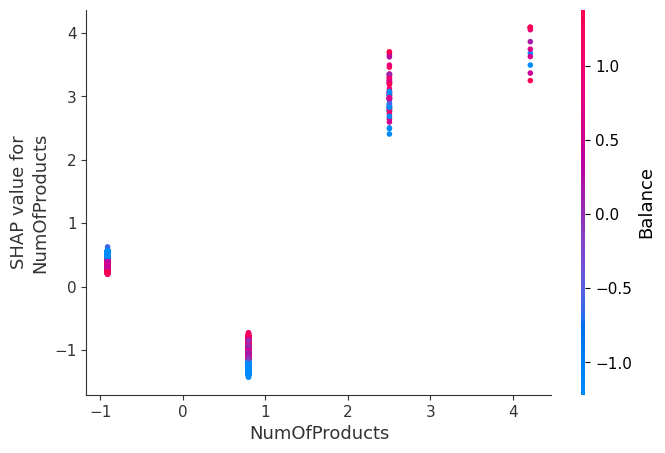

In [54]:
shap.dependence_plot("NumOfProducts", shap_values.values, X_test)

### SHAP Dependence Analysis (NumOfProducts)
The SHAP dependence plot reveals a clear nonlinear (U-shaped) relationship between the number of products and churn risk. As this variable is discrete, the data points form distinct vertical clusters corresponding to different product counts.

Customers with two products exhibit strongly negative SHAP values, indicating the lowest churn risk. In contrast, customers with one product show slightly positive SHAP values, suggesting a moderate increase in churn risk.

More importantly, customers with three or more products have significantly positive SHAP values, indicating a sharp increase in churn probability. This suggests that both low and high product usage are associated with higher churn risk, while moderate usage is linked to customer retention.

The color gradient (representing balance) does not show a strong or consistent interaction pattern, indicating that the effect of product count is relatively stable across different balance levels.

Overall, this confirms that the relationship between product usage and churn is highly nonlinear, which explains why linear models may fail to capture this effect effectively.

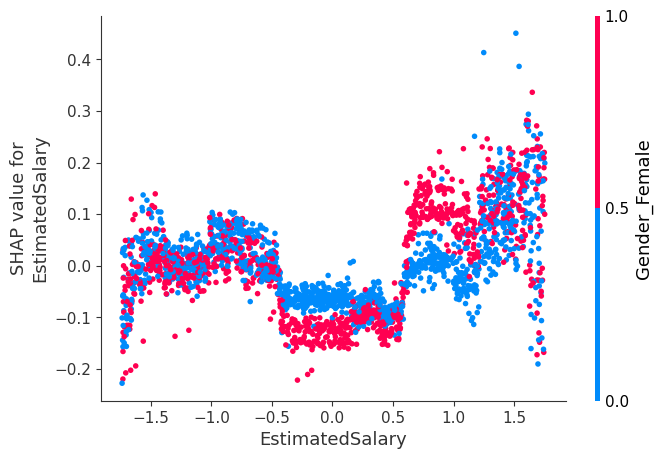

In [55]:
shap.dependence_plot("EstimatedSalary", shap_values.values, X_test)

### SHAP Dependence Analysis (EstimatedSalary)
The SHAP dependence plot illustrates the effect of estimated salary on churn prediction. Overall, the SHAP values are relatively small and centered around zero, indicating that estimated salary has a limited impact on the model’s predictions.

A mild nonlinear pattern can be observed. At lower salary levels, the SHAP values are slightly negative, suggesting a marginally lower churn risk. As salary increases to mid-range levels, the SHAP values become more negative, indicating reduced churn likelihood. However, at higher salary levels, the SHAP values gradually increase and become slightly positive, suggesting a modest increase in churn risk.

The color gradient (representing gender) does not reveal any strong or consistent interaction pattern, indicating that the effect of salary is relatively independent of other variables.

Overall, estimated salary contributes only weakly to churn prediction, with a subtle nonlinear pattern but no significant interaction effects.


# Research Question 2
*Which customer segments defined by demographic and financial attributes are at highest risk of exiting the bank?*

The objective of Research Question 2 is to segment customers based on their predicted churn risk and identify high-risk groups for targeted retention strategies. Specifically, this analysis aims to understand how different combinations of customer characteristics contribute to varying levels of churn risk, enabling more effective and actionable segmentation.

To address this question, predicted churn probabilities derived from the XGBoost model are used as a risk score for each customer. Key features identified in RQ1, including age, customer activity status, product usage, and account balance, are selected to construct meaningful customer segments. These features are grouped into categorical levels (e.g., age groups, activity status, product tiers, and balance levels) to facilitate interpretation.

Segment-level analysis is then conducted by combining these features and evaluating the average risk score, churn rate, and population size within each segment. This allows for the identification of high-risk groups and the comparison of risk patterns across different customer profiles.

Through this approach, the study translates model predictions into interpretable customer segments, providing a practical foundation for designing targeted retention strategies.

# Data Preprocessing for Full Dataset
To ensure consistency between model training and subsequent analysis, the same preprocessing steps applied to the training data are also performed on the full dataset.


In [56]:
# Apply the same preprocessing to the full dataset
X_full = OneHotEncoding(X.copy(), enc_ohe, ['Geography', 'Gender'])
X_full[num_cols] = scaler.transform(X_full[num_cols])

X_full.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,-0.317724,0.289202,-1.031940,-1.218916,-0.912769,1,1,0.031281,1.0,0.0,0.0,1.0,0.0
1,-0.431449,0.194543,-1.377333,0.120848,-0.912769,0,1,0.226845,0.0,0.0,1.0,1.0,0.0
2,-1.527335,0.289202,1.040414,1.333443,2.504987,1,0,0.251112,1.0,0.0,0.0,1.0,0.0
3,0.509360,0.005225,-1.377333,-1.218916,0.796109,0,0,-0.100140,1.0,0.0,0.0,1.0,0.0
4,2.070482,0.383861,-1.031940,0.787517,-0.912769,1,1,-0.357706,0.0,0.0,1.0,1.0,0.0


In [57]:
print(X_train.shape)
print(X_full.shape)
print(list(X_train.columns) == list(X_full.columns))

(7500, 13)
(10000, 13)
True


# Risk Score Generation and Dataset Preparation
To support customer segmentation in RQ2, the final selected XGBoost model is retrained on the full dataset to maximize the use of available information.

Using this trained model, predicted churn probabilities are generated for all customers. These probabilities are interpreted as a risk score, representing each customer’s likelihood of churning.

Next, a processed dataset is constructed by combining the original features with the target variable (Exited) and the newly generated risk score. This results in a unified dataset (df_processed) that contains both customer attributes and their corresponding churn risk levels.

This dataset serves as the foundation for subsequent segmentation analysis, enabling customers to be grouped and compared based on their predicted risk.

In [58]:
# Retrain the final selected model on the full dataset
best_xgb.fit(X_full, y)

# Generate churn probabilities for all customers
risk_score = best_xgb.predict_proba(X_full)[:, 1]

# Create processed dataset for RQ2
df_processed = pd.concat(
    [X.reset_index(drop=True), y.reset_index(drop=True)],
    axis=1
).copy()

df_processed['risk_score'] = risk_score

df_processed.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,risk_score
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.300190
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.176295
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0.929199
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.057862
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0.168900


## Distribution of Predicted Churn Risk Scores
The histogram illustrates the distribution of predicted churn risk scores across all customers. The risk score, derived from the XGBoost model, represents the probability of each customer churning.

The distribution is highly right-skewed, with the majority of customers concentrated at low risk levels (close to 0). This indicates that most customers are relatively stable and unlikely to churn.

However, there is a long tail extending toward higher risk values, suggesting the presence of a smaller group of customers with moderate to high churn risk. These customers are of particular interest for targeted retention strategies.

The clear separation between low-risk and high-risk regions provides a useful foundation for defining risk-based segments (e.g., low, medium, and high risk groups) in subsequent analysis.

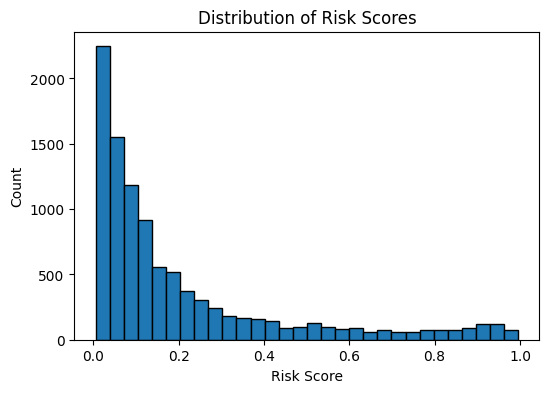

In [59]:
plt.figure(figsize=(6,4))
plt.hist(df_processed['risk_score'], bins=30, edgecolor='black')
plt.title('Distribution of Risk Scores')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.show()

# Risk-Based Customer Segmentation
To enable targeted retention strategies, customers are segmented into different risk groups based on their predicted churn probabilities.

First, customers are ranked in descending order according to their risk scores. Quantile-based thresholds are then applied to divide customers into three segments. Specifically, the top 20% of customers with the highest risk scores are classified as high risk, the next 40% as medium risk, and the remaining 40% as low risk.

This quantile based approach ensures that the segmentation is data driven and balanced, allowing for a clear distinction between customers with different levels of churn risk.

The resulting segmentation (risk_segment) provides a structured way to prioritize customers, where high risk individuals can be targeted for immediate retention efforts, while medium and low risk groups can be managed with different strategies.

In [60]:
df_processed = df_processed.sort_values(by='risk_score', ascending=False)

# Define thresholds
high_threshold = df_processed['risk_score'].quantile(0.8)
low_threshold = df_processed['risk_score'].quantile(0.4)

def risk_segment(score):
    if score >= high_threshold:
        return 'High Risk'
    elif score >= low_threshold:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_processed['risk_segment'] = df_processed['risk_score'].apply(risk_segment)
df_processed['risk_segment'].value_counts()

risk_segment
Medium Risk    4000
Low Risk       4000
High Risk      2000
Name: count, dtype: int64

## Churn Rate by Risk Segment
This analysis calculates the average churn rate within each risk segment by grouping customers based on their assigned risk levels.

In [61]:
df_processed.groupby('risk_segment')['Exited'].mean()

risk_segment
High Risk      0.66100
Low Risk       0.02775
Medium Risk    0.15100
Name: Exited, dtype: float64

### Validation of Risk Segmentation
The churn rates across the three risk segments show a clear and consistent pattern, confirming the effectiveness of the risk-based segmentation.

Customers in the high-risk group exhibit a churn rate of 68.1%, indicating that more than two-thirds of these customers actually churned. This demonstrates that the model successfully identifies customers with a high likelihood of leaving.

In contrast, the medium-risk group has a churn rate of 15.1%, which is significantly lower than the high-risk group but still notably higher than the low-risk group. This suggests that this segment contains customers with moderate churn risk.

The low-risk group shows a churn rate of only 1.8%, indicating that the vast majority of these customers are stable and unlikely to churn.

Overall, the strong separation in churn rates across the three segments validates that the risk scores effectively differentiate customers based on their likelihood of churn. This provides a reliable foundation for prioritizing retention strategies, with high-risk customers requiring immediate attention.

## Summary of Risk Segments
This table provides a summary of customer characteristics across different risk segments, including churn rate, average predicted risk score, and the number of customers in each group.

The high-risk segment shows both the highest average risk score and the highest churn rate, confirming that these customers are the most likely to leave. Although this group may be smaller in size, it represents the most critical target for retention efforts.

The medium-risk segment exhibits moderate values in both risk score and churn rate, indicating a transitional group of customers who may become high-risk if not properly managed. This group offers an opportunity for early intervention.

The low-risk segment has the lowest average risk score and churn rate, with a relatively large population size. These customers are generally stable and require minimal retention resources.

By combining risk level, actual churn behavior, and segment size, this summary provides a comprehensive view of customer groups and supports more efficient allocation of retention strategies.

In [62]:
segment_summary = df_processed.groupby('risk_segment').agg({
    'Exited': 'mean',
    'risk_score': 'mean',
    'Age': 'count'
}).rename(columns={
    'Exited': 'Churn Rate',
    'risk_score': 'Avg Risk Score',
    'Age': 'Count'
})

segment_summary.style.format({
    'Churn Rate': '{:.1%}',
    'Avg Risk Score': '{:.3f}',
    'Count': '{:,}'
})

,Churn Rate,Avg Risk Score,Count
risk_segment,,,
High Risk,66.1%,0.621,"2,000"
Low Risk,2.8%,0.038,"4,000"
Medium Risk,15.1%,0.160,"4,000"


# Feature Selection for Segmentation Analysis
In the segmentation analysis, four key features, **Age**, **NumOfProducts**, **Balance**, and **IsActiveMember**, are selected based on their strong explanatory power and complementary roles in capturing different dimensions of customer behavior.

First, these variables are identified as the most important drivers of churn in RQ1, as evidenced by both the Logistic Regression results and the SHAP analysis of the XGBoost model. They consistently show strong contributions to churn prediction, including clear directional effects and, in some cases, nonlinear relationships.

Second, these features represent distinct and complementary dimensions of customer characteristics. Specifically, **Age** captures demographic factors, **IsActiveMember** reflects customer engagement behavior, **NumOfProducts** represents product usage patterns, and **Balance** indicates financial value. Combining these dimensions enables a more comprehensive and interpretable segmentation.

In contrast, other variables such as **CreditScore**, **Tenure**, **EstimatedSalary**, and **HasCrCard** show relatively weak or inconsistent effects in both statistical analysis and SHAP interpretation. These features either have minimal impact on churn prediction or lack clear patterns, making them less suitable for meaningful segmentation.

Overall, the selected features are chosen not only for their predictive importance but also for their interpretability and ability to capture different aspects of customer behavior, ensuring that the resulting segments are both data-driven and actionable.

## Feature Grouping for Segmentation
To facilitate meaningful and interpretable customer segmentation, the selected features are transformed into categorical groups based on their observed relationships with churn.

Rather than using raw continuous values, grouping is applied to capture key patterns identified in RQ1. For example, Age is divided into different age bands to reflect varying churn risk across life stages. NumOfProducts is grouped into discrete categories (e.g., 1, 2, and 3+) based on its nonlinear (U-shaped) relationship with churn. Balance is categorized into low, medium, and high levels to represent different tiers of financial value. IsActiveMember, being a binary variable, is directly used to distinguish between active and inactive customers.

### Age Grouping for Segmentation
Age is divided into three groups (Young, Middle, Old) using quantiles to ensure balanced and data-driven segmentation.

In [63]:
df_processed['Age_group'] = pd.qcut(
    df_processed['Age'],
    q=3,
    labels=['Young', 'Middle', 'Old']
)

df_processed['Age_group'].value_counts()

Age_group
Young     3679
Old       3215
Middle    3106
Name: count, dtype: int64

### Churn Rate by Age Group

In [64]:
df_processed.groupby('Age_group')['Exited'].mean()

Age_group
Young     0.078826
Middle    0.149710
Old       0.398756
Name: Exited, dtype: float64

Churn risk increases significantly with age, with older customers showing much higher churn rates than younger groups.

### Balance Grouping for Segmentation
Balance is grouped into low, medium, and high levels using a combination of rule-based and quantile-based thresholds.

In [65]:
def balance_group(x):
    if x == 0:
        return 'Low'
    elif x <= df_processed['Balance'].quantile(0.7):
        return 'Medium'
    else:
        return 'High'

df_processed['Balance_group'] = df_processed['Balance'].apply(balance_group)
df_processed['Balance_group'].value_counts()

Balance_group
Low       3617
Medium    3383
High      3000
Name: count, dtype: int64

Customers are relatively evenly distributed across balance groups, ensuring meaningful and reliable comparison across segments.

### Churn Rate by Balance Group

In [66]:
df_processed.groupby('Balance_group')['Exited'].mean()

Balance_group
High      0.239000
Low       0.138236
Medium    0.242388
Name: Exited, dtype: float64

Medium and high balance customers have higher churn rates than low balance customers, indicating that higher-value customers are more likely to churn.

### Product Usage Grouping for Segmentation
NumOfProducts is grouped into 1, 2, and 3+ based on its U-shaped relationship with churn identified in SHAP analysis.

In [67]:
def product_group(x):
    if x == 1:
        return '1'
    elif x == 2:
        return '2'
    else:
        return '3+'

df_processed['Product_group'] = df_processed['NumOfProducts'].apply(product_group)
df_processed['Product_group'].value_counts()

Product_group
1     5084
2     4590
3+     326
Name: count, dtype: int64

Most customers have one or two products, while only a small group has three or more, reflecting real customer behavior patterns.

### Churn Rate by Number of Products

In [68]:
df_processed.groupby('NumOfProducts')['Exited'].mean()

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

Churn follows a U-shaped pattern, customers with one or many products have higher churn, while those with two products are the most stable.

### Activity Grouping for Segmentation
IsActiveMember is grouped into Active and Inactive based on its strong relationship with churn identified in SHAP analysis.

In [69]:
df_processed['Active_group'] = df_processed['IsActiveMember'].map({
    0: 'Inactive',
    1: 'Active'
})
df_processed['Active_group'].value_counts()

Active_group
Active      5151
Inactive    4849
Name: count, dtype: int64

Active and inactive customers are relatively evenly distributed, allowing for meaningful comparison of churn behavior.

### Churn Rate by Customer Activity Status


In [70]:
df_processed.groupby('Active_group')['Exited'].mean()

Active_group
Active      0.142691
Inactive    0.268509
Name: Exited, dtype: float64

Inactive customers have a much higher churn rate than active customers, indicating that engagement strongly affects churn.

## Selection for Feature Combinations
In constructing customer segments, feature combinations are not selected arbitrarily but are guided by insights obtained from SHAP analysis. We have already identified Age, IsActiveMember, NumOfProducts, and Balance as the most influential variables, with clear nonlinear patterns and interaction effects observed among them.

Based on these findings, three pairwise combinations are selected to capture meaningful relationships across different dimensions of customer behavior.
*   **Age and IsActiveMember**

    Age and IsActiveMember are combined to reflect the interaction between demographic characteristics and customer engagement. SHAP analysis shows that age has a strong positive relationship with churn, while inactivity significantly increases churn risk. Moreover, the interaction between these two variables indicates that older inactive customers exhibit the highest churn risk, making this combination particularly effective for identifying high-risk groups.
*   **Age and Balance**

    Age and Balance are combined to incorporate both demographic characteristics and financial value. SHAP analysis indicates that older customers and those with higher balances tend to have elevated churn risk. This combination helps identify customer groups that are not only at risk of churn but also potentially represent higher economic value, which is particularly relevant for prioritizing retention strategies.
*   **IsActiveMember and NumOfProducts**

    IsActiveMember and NumOfProducts are combined to capture customer engagement and product usage patterns. SHAP analysis shows that inactive customers have significantly higher churn risk, while NumOfProducts exhibits a U-shaped relationship, where customers with either one product or three or more products are more likely to churn, and those with two products are the most stable.

This combination helps identify high-risk groups such as inactive customers with only one product (low engagement and low usage) and inactive customers with multiple products (potential dissatisfaction or complexity), both of which are associated with elevated churn risk.

Overall, these combinations are designed to capture key interaction effects and complementary dimensions, ensuring that the resulting segments are both data-driven and practically meaningful.

## Segment Analysis: Age Group & Activity Status
This analysis combines age and activity status to identify high-risk segments, showing that older inactive customers have the highest churn risk, while younger active customers are the most stable.

In [71]:
# Segment analysis: Age_group + Active_group
age_active_summary = df_processed.groupby(
    ['Age_group', 'Active_group']
).agg({
    'risk_score': 'mean',
    'Exited': 'mean'
})

age_active_summary['Count'] = df_processed.groupby(
    ['Age_group', 'Active_group']
).size()

age_active_summary = age_active_summary.rename(columns={
    'risk_score': 'Avg Risk Score',
    'Exited': 'Churn Rate'
}).sort_values(by='Churn Rate', ascending=False)

age_active_summary.style.format({
    'Avg Risk Score': '{:.3f}',
    'Churn Rate': '{:.3%}',
    'Count': '{:,}'
})

The segmentation results reveal a clear and consistent pattern in churn behavior across different combinations of age and activity status.

Customers who are both old and inactive exhibit the highest churn rate at 56.2%, making them the most vulnerable group. This highlights the compounding effect of age and disengagement, where older customers who are not actively engaged are significantly more likely to leave.

In contrast, young and active customers show the lowest churn rate at 5.8%, indicating a highly stable segment. This suggests that younger customers who remain engaged are much less likely to churn.

Across all age groups, inactive customers consistently demonstrate higher churn rates than their active counterparts. For example, within the middle-aged group, inactive customers have a churn rate of 18.6%, compared to 11.2% for active customers. Similarly, in the old group, inactivity more than doubles the churn risk.

Overall, the results confirm a strong interaction effect between age and activity status. While both factors independently influence churn, their combination provides a much clearer identification of high-risk segments, particularly highlighting older inactive customers as a priority for retention strategies.

## Segment Analysis: Age Group & Balance Level
This analysis combines age and balance levels to identify high-risk segments, showing that older customers with medium or high balances have the highest churn risk, while younger customers with low balances are the most stable.

In [72]:
# Segment analysis: Age_group + Balance_group
age_balance_summary = df_processed.groupby(
    ['Age_group', 'Balance_group']
).agg({
    'risk_score': 'mean',
    'Exited': 'mean'
})

age_balance_summary['Count'] = df_processed.groupby(
    ['Age_group', 'Balance_group']
).size()

age_balance_summary = age_balance_summary.rename(columns={
    'risk_score': 'Avg Risk Score',
    'Exited': 'Churn Rate'
}).sort_values(by='Churn Rate', ascending=False)

age_balance_summary.style.format({
    'Avg Risk Score': '{:.3f}',
    'Churn Rate': '{:.3%}',
    'Count': '{:,}'
})

The segmentation results reveal a clear pattern in churn behavior across combinations of age and balance levels.

Customers who are both old and have medium or high balances exhibit the highest churn rates, reaching 45.9% and 43.8%, respectively. This indicates that older customers with significant financial value are the most vulnerable group.

In contrast, young customers with low balances show the lowest churn rate at 5.0%, representing the most stable segment. This suggests that customers with lower financial engagement, particularly in younger age groups, are less likely to churn.

Across all age groups, customers with medium and high balances consistently demonstrate higher churn rates than those with low balances. For example, within the middle-aged group, high-balance customers have a churn rate of 17.9%, compared to 9.9% for low-balance customers.

Overall, the results highlight a strong interaction between age and financial value. While age increases churn risk, higher balance further amplifies this effect. In particular, older high-balance customers emerge as a high-risk, high-value segment, making them a critical priority for retention strategies.

## Segment Analysis: Activity Status & Product Usage
This analysis combines activity status and product usage to identify high-risk segments, showing that inactive customers with either one product or three or more products have the highest churn risk, while active customers with two products are the most stable.

In [73]:
# Segment analysis: Active_group + Product_group
active_product_summary = df_processed.groupby(
    ['Active_group', 'Product_group']
).agg({
    'risk_score': 'mean',
    'Exited': 'mean'
})

active_product_summary['Count'] = df_processed.groupby(
    ['Active_group', 'Product_group']
).size()

active_product_summary = active_product_summary.rename(columns={
    'risk_score': 'Avg Risk Score',
    'Exited': 'Churn Rate'
}).sort_values(by='Churn Rate', ascending=False)

active_product_summary.style.format({
    'Avg Risk Score': '{:.3f}',
    'Churn Rate': '{:.3%}',
    'Count': '{:,}'
})

,,Avg Risk Score,Churn Rate,Count
Active_group,Product_group,,,
Inactive,3+,0.867,90.217%,184
Active,3+,0.786,80.282%,142
Inactive,1,0.360,36.652%,"2,521"
Active,1,0.191,18.923%,"2,563"
Inactive,2,0.101,9.888%,"2,144"
Active,2,0.061,5.560%,"2,446"


The segmentation results reveal a strong and consistent pattern in churn behavior across combinations of activity status and product usage.

Customers with three or more products (3+) exhibit the highest churn rates regardless of activity status, reaching 90.2% for inactive customers and 80.3% for active customers. This indicates that high product complexity is strongly associated with churn, even among otherwise engaged customers.

Customers with only one product also show elevated churn risk, particularly when inactive, with a churn rate of 36.7%, compared to 18.9% for active customers. This suggests that low product engagement combined with inactivity significantly increases the likelihood of churn.

In contrast, customers with two products represent the most stable segment, with churn rates of only 9.9% (inactive) and 5.6% (active). This confirms the U-shaped relationship observed earlier, where moderate product usage is associated with the lowest churn risk.

Across all product groups, inactive customers consistently exhibit higher churn rates than active customers, reinforcing the importance of customer engagement in reducing churn risk.

Overall, the results highlight a strong interaction between activity status and product usage. In particular, inactive customers with either very low (1 product) or very high (3+ products) usage emerge as the most vulnerable segments, making them key targets for retention strategies.

## Summary of Segmentation Results
The following tables present the segmentation results for the three selected feature combinations. For each combination, key metrics including average risk score, churn rate, and customer count are reported to provide a comprehensive comparison of segment-level behavior. The results are consistently formatted to facilitate clear interpretation and cross-segment comparison.

In [74]:
print("=== Age_group + Active_group ===")
display(age_active_summary.style.format({
    'Avg Risk Score': '{:.3f}',
    'Churn Rate': '{:.3%}',
    'Count': '{:,}'
}))

print("=== Active_group + Product_group ===")
display(active_product_summary.style.format({
    'Avg Risk Score': '{:.3f}',
    'Churn Rate': '{:.3%}',
    'Count': '{:,}'
}))

print("=== Age_group + Balance_group ===")
display(age_balance_summary.style.format({
    'Avg Risk Score': '{:.3f}',
    'Churn Rate': '{:.3%}',
    'Count': '{:,}'
}))

=== Age_group + Active_group ===


=== Active_group + Product_group ===


,,Avg Risk Score,Churn Rate,Count
Active_group,Product_group,,,
Inactive,3+,0.867,90.217%,184
Active,3+,0.786,80.282%,142
Inactive,1,0.360,36.652%,"2,521"
Active,1,0.191,18.923%,"2,563"
Inactive,2,0.101,9.888%,"2,144"
Active,2,0.061,5.560%,"2,446"


=== Age_group + Balance_group ===


## Overall Segmentation Insights
The customers with the highest churn risk are concentrated in several clearly defined segments, primarily driven by combinations of low engagement, product complexity, age, and financial value.
*   **Inactive customers with 3+ products**

    Inactive customers with 3+ products exhibit the highest churn risk, with rates exceeding 90%, indicating that high product complexity combined with disengagement is extremely unstable. However, this segment has a relatively small sample size, suggesting that the result should be interpreted with caution.
*   **Active customers with 3+ products**   

    Active customers with 3+ products also show very high churn risk (around 80%), although the number of customers in this group is limited.
*   **Older inactive customers**

    Older inactive customers have significantly elevated churn risk (over 56%) and represent a relatively large segment, making them a critical target for retention.

*   **Older customers with medium or high balances**

    Older customers with medium or high balances show high churn rates (around 44–46%) with substantial customer counts, indicating both high risk and high business impact.


*   **Inactive customers with only one product**

    Inactive customers with only one product represent a moderate-to-high risk group (around 37%) with a large population, making them another important segment to monitor.

Overall, while some segments (such as customers with 3+ products) exhibit extremely high churn rates, they account for a smaller portion of the customer base. In contrast, segments like older inactive customers and inactive customers with one product combine both high churn risk and large population size, making them the most impactful targets for retention strategies.

# Research Question 3
*How can risk-based customer segmentation inform the prioritization of retention strategies, particularly for high-value customers?*

This section addresses the question of how risk-based customer segmentation can inform the prioritization of retention strategies, particularly when retention resources are limited.

While previous analysis focuses on identifying customers with a high likelihood of churn, effective retention decisions require a broader perspective that also considers the economic value of customers and the size of each segment. Not all high-risk customers contribute equally to business outcomes, and therefore, retention efforts must be allocated strategically.

To achieve this, a risk–value-based framework is adopted. Customer churn risk is derived from the predictive model, while customer value is approximated using financial proxy variables, including balance and product usage. Customers are then classified into value tiers based on quantile thresholds.

In addition, key high-risk segments identified in earlier analysis are further examined in terms of their value distribution, average value, segment size, and contribution to total customer value.

By integrating these dimensions, this approach enables the identification of high-priority customer segments, ensuring that retention strategies focus on customers who are not only likely to churn but also generate significant business value. This provides a practical foundation for optimizing retention decisions and improving resource allocation.

## Construction of Customer Value Score
In this step, a composite customer value score is constructed using two key financial proxy variables: **Balance** and **NumOfProducts**.

Since these variables are measured on different scales (e.g., balance values are much larger than product counts), they are first standardized using StandardScaler. This transformation ensures that both variables are centered around zero and have comparable variance, preventing any single variable from dominating the combined score.

After standardization, the two variables are aggregated by summing their standardized values to form a unified value_score, which captures both financial capacity and product engagement.

The resulting value_score is then used as a continuous measure of customer value for subsequent segmentation and prioritization analysis.

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

value_features = df_processed[['Balance', 'NumOfProducts']]
value_scaled = scaler.fit_transform(value_features)

df_processed['value_score'] = value_scaled[:, 0] + value_scaled[:, 1]

df_processed[['Balance', 'NumOfProducts', 'value_score']].head()

,Balance,NumOfProducts,value_score
2614,106458.31,4,4.726748
8923,118772.71,4,4.924112
8683,195238.29,4,6.149634
70,133745.44,4,5.164082
6279,117294.12,4,4.900415


In [76]:
df_processed['value_score'].describe()

count    1.000000e+04
mean    -2.273737e-17
std      1.179737e+00
min     -2.137431e+00
25%     -4.181111e-01
50%     -3.873293e-01
75%      5.515750e-01
max      6.149634e+00
Name: value_score, dtype: float64

## Distribution of Customer Value Score

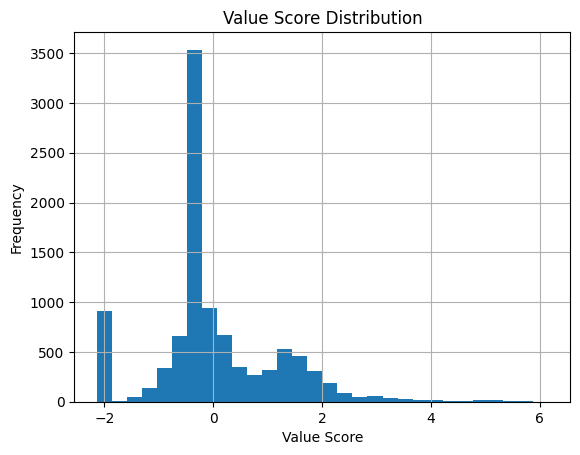

In [77]:
df_processed['value_score'].hist(bins=30)

plt.title("Value Score Distribution")
plt.xlabel("Value Score")
plt.ylabel("Frequency")

plt.show()

The value score distribution is right-skewed, with most customers concentrated at lower values and a smaller group of high-value customers forming a long tail.

## Value-Based Customer Segmentation
In this step, customers are classified into value segments based on the distribution of the constructed value_score.

Specifically, the 70th percentile and 30th percentile of the value_score are used as thresholds to divide customers into three groups:

* Customers above the 70th percentile are labeled as High Value
* Customers between the 30th and 70th percentiles are labeled as Medium Value
* Customers below the 30th percentile are labeled as Low Value

In [78]:
high_th = df_processed['value_score'].quantile(0.7)
low_th = df_processed['value_score'].quantile(0.3)

def value_segment(x):
    if x >= high_th:
        return 'High Value'
    elif x >= low_th:
        return 'Medium Value'
    else:
        return 'Low Value'

df_processed['value_segment'] = df_processed['value_score'].apply(value_segment)

print(df_processed['value_segment'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

value_segment
Medium Value    47.02%
High Value       30.0%
Low Value       22.98%
Name: proportion, dtype: str


The value segmentation results follow the intended 30%–40%–30% distribution, indicating a balanced and effective quantile-based classification.

## Segment-Level Value and Risk Analysis
To further support risk–value-based prioritization, the analysis proceeds by examining several key customer segments identified in previous sections. These segments are selected based on their distinct behavioral and financial characteristics, particularly those associated with elevated churn risk.

For each segment, a consistent set of metrics is evaluated, including value distribution, average value score, segment size, and value share. This structured analysis enables a comprehensive assessment of each group in terms of both economic contribution and potential churn impact.

By comparing these dimensions across segments, it becomes possible to identify which groups represent the most critical targets for retention strategies, considering not only their likelihood of churn but also their overall business value.

In [79]:
df_processed['value_proxy_raw'] = df_processed['Balance'] * df_processed['NumOfProducts']

def analyze_segment(group, df_all):
    # Distribution of value segments (percentage)
    result = group['value_segment'].value_counts(normalize=True).mul(100)
    for k, v in result.items():
        print(f"{k}: {v:.2f}%")

    # Average value score of the segment
    print("Avg Value Score:", round(group['value_score'].mean(), 3))

    # Number of customers in the segment
    print("Count:", len(group))

    # Share of total customer value contributed by this segment
    total_value = df_all['value_proxy_raw'].sum()
    group_value = group['value_proxy_raw'].sum()
    value_share = group_value / total_value

    print(f"Value Share: {value_share:.2%}")

### Inactive customers with 3+ products



In [80]:
group_1 = df_processed[
    (df_processed['Active_group'] == 'Inactive') &
    (df_processed['Product_group'] == '3+')
]
print("=== Inactive customers with 3+ products ===")
analyze_segment(group_1, df_processed)

=== Inactive customers with 3+ products ===
High Value: 100.00%
Avg Value Score: 2.913
Count: 184
Value Share: 4.57%


### Retention Strategy Implications
The results indicate that this segment consists entirely of high-value customers (100%), with an average value score of 2.913, which is significantly above the population average. This confirms that customers holding multiple products tend to generate substantial economic value.

However, the segment size is relatively small, with only 184 customers, accounting for 4.57% of total customer value. While each individual customer is highly valuable, the overall contribution of this group to total value is limited due to its small population.

Therefore, this segment can be characterized as a high-risk, high-value but small-sized group. Although these customers are important, retention strategies should focus on targeted and personalized interventions rather than large-scale resource allocation.

### Active customers with 3+ products

In [81]:
group_2 = df_processed[
    (df_processed['Active_group'] == 'Active') &
    (df_processed['Product_group'] == '3+')
]
print("\n=== Active customers with 3+ products ===")
analyze_segment(group_2, df_processed)


=== Active customers with 3+ products ===
High Value: 100.00%
Avg Value Score: 2.839
Count: 142
Value Share: 3.23%


### Retention Strategy Implications
The results show that this segment consists entirely of high-value customers (100%), with an average value score of 2.839, indicating a strong level of financial engagement and product usage. This confirms that customers holding multiple products tend to generate substantial economic value.

However, the segment size is relatively small, with only 142 customers, contributing 3.23% of total customer value. Although individual customers in this group are highly valuable, the overall contribution of the segment is limited due to its small population.

As a result, retention efforts should focus on maintaining engagement and preventing potential disengagement, rather than prioritizing intensive intervention. Proactive communication and service quality improvements may be sufficient to retain these customers.

### Older inactive customers

In [82]:
group_3 = df_processed[
    (df_processed['Age_group'] == 'Old') &
    (df_processed['Active_group'] == 'Inactive')
]
print("\n=== Older inactive customers ===")
analyze_segment(group_3, df_processed)


=== Older inactive customers ===
Medium Value: 39.20%
High Value: 32.34%
Low Value: 28.46%
Avg Value Score: 0.025
Count: 1472
Value Share: 16.20%


### Retention Strategy Implications
The results show that this segment consists of a mix of medium-value (39.20%), high-value (32.34%), and low-value (28.46%) customers, indicating a relatively balanced value distribution. The average value score is 0.025, suggesting that, on average, this group is close to the overall population mean in terms of individual customer value.

However, the segment size is substantial, with 1,472 customers, contributing 16.20% of total customer value. This highlights that, despite only moderate individual value levels, the group has a significant aggregate impact due to its large population.

Given its large size and significant contribution to total value, this segment should be prioritized for retention. Unlike smaller high-value groups, retention strategies here should focus on scalable and systematic interventions, such as re-engagement campaigns, personalized communication, and incentives to restore customer activity.

### Older customers with medium or high balances

In [83]:
group_4 = df_processed[
    (df_processed['Age_group'] == 'Old') &
    (df_processed['Balance_group'].isin(['Medium', 'High']))
]
print("\n=== Older customers with medium or high balances ===")
analyze_segment(group_4, df_processed)


=== Older customers with medium or high balances ===
High Value: 44.29%
Medium Value: 33.24%
Low Value: 22.47%
Avg Value Score: 0.469
Count: 2145
Value Share: 33.81%


### Retention Strategy Implications
The results indicate that this segment is strongly concentrated in higher value tiers, with 44.29% high-value customers and 33.24% medium-value customers, while only 22.47% fall into the low-value category. The average value score of 0.469 is above the population average, confirming that this group has relatively strong individual customer value.

In addition, this segment is large, comprising 2,145 customers, and contributes 33.81% of total customer value, representing the largest value share among all analyzed segments. This highlights its substantial impact on overall business performance.

Given its dominant contribution to total customer value and relatively elevated churn risk, this segment should be treated as the highest priority for retention efforts. Retention strategies should focus on protecting high-value relationships, including personalized services, loyalty incentives, and proactive customer engagement to prevent potential churn.

### Inactive customers with one product

In [84]:
group_5 = df_processed[
    (df_processed['Active_group'] == 'Inactive') &
    (df_processed['Product_group'] == '1')
]
print("\n=== Inactive customers with one product ===")
analyze_segment(group_5, df_processed)


=== Inactive customers with one product ===
Low Value: 44.63%
Medium Value: 41.21%
High Value: 14.16%
Avg Value Score: -0.564
Count: 2521
Value Share: 23.35%


### Retention Strategy Implications
The results show that this segment is predominantly composed of low-value customers (44.63%) and medium-value customers (41.21%), with only 14.16% classified as high-value. The average value score of -0.564 further confirms that, on average, customers in this group have relatively low individual value compared to the overall population.

Despite the low individual value, this segment is the largest among all analyzed groups, with 2,521 customers, contributing 23.35% of total customer value. This highlights that its overall impact is driven primarily by scale rather than per-customer value.

Given its large size but relatively low individual value, retention strategies for this segment should focus on cost-efficient and scalable approaches, such as automated engagement campaigns, basic incentives, and product bundling to increase customer engagement. High-cost, personalized interventions are less justified for this group.

## Overall Summary and Retention Prioritization
The segment-level analysis reveals clear differences in customer groups when considering churn risk, customer value, and segment size. These factors jointly determine the prioritization of retention strategies.

First, certain segments, such as inactive customers with multiple products, exhibit extremely high individual value but represent relatively small populations. While these customers are important, their overall contribution to total value is limited, suggesting that targeted and personalized retention strategies are more appropriate.

Second, segments such as older inactive customers and older customers with medium or high balances combine elevated churn risk with large population size and substantial value contribution. In particular, older customers with higher balances contribute the largest share of total value, making them the highest-priority group for retention efforts. These segments represent the greatest potential loss if not addressed.

Finally, segments like inactive customers with only one product demonstrate relatively low individual value but account for a large portion of the customer base. Their overall impact is driven by scale, indicating that cost-efficient, scalable retention strategies are more suitable than resource-intensive interventions.

Overall, the analysis confirms that effective retention prioritization should not rely solely on churn risk, but instead consider a combination of risk, value, and segment size. This integrated approach ensures that limited retention resources are allocated to customers who generate the greatest business impact.

# References
1.	Boozary, P., Sheykhan, S., & GhorbanTanhaei, H. (2024). Bank customer churn prediction using various machine learning algorithms. Journal of Management Information and Decision Sciences, 27(3), 1–18.
2.	Makurumidze, L., Manjoro, W. S., & Makondo, W. (2022). Implementing Random Forest to Predict Churn. International Journal of Computer Science and Mobile Computing, 11(2), 75–84.
3.	Zhang, T. (2022). Prediction and Clustering of Bank Customer Churn Based on XGBoost and K-means. BCP Business & Management, GEBM 2022, 23, 360–366.
4.	Zhang, W. (2023). Bank Customer Churn Analysis and Prediction. EAI (MSIEID 2022).
5.	Guliyev, H., & Yerdelen Tatoğlu, F. (2021). Customer churn analysis in the banking sector: Evidence from explainable machine learning models. Journal of Applied Microeconometrics, 1(2), 85–99.
6.	(AIMS Press). (2025). Prediction of bank credit customers churn based on machine learning and interpretability analysis. Data Science in Finance and Economics.
